<a href="https://colab.research.google.com/github/Kafleavinash/Machinelearning_soil/blob/main/catboost_model_cbm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()


Saving Antho_Test_1_field.csv to Antho_Test_1_field.csv


In [ ]:
import numpy as np
import pandas as pd

In [ ]:
df = pd.read_csv("/content/cleaned_file_OM_withoutfield_1.csv")
df_cleaned = df.loc[:, ~df.columns.str.contains('^Unnamed')]
df_cleaned.to_csv("cleaned_file.csv", index=False)


In [ ]:
df = pd.read_csv("/content/cleaned_file_OM_withoutfield_1.csv")
df_cleaned = df.loc[:, ~df.columns.str.contains('^Unnamed')]
df_cleaned.to_csv("cleaned_file.csv", index=False)


In [ ]:
# Drop the dependent variable from the dataset to get the features (X)
X = df.drop(columns=["OM"])  # <-- replace with actual column name if different

# Select the dependent variable (y)
y = df["OM"]


In [ ]:
df_m = df

In [ ]:
df_m.head()

,SAMPLEDATE,lati,long,OM,Relative_Elev,Slope,Aspect,Profile_curva,Tang_curva,Polaris_SC,...,Theta_s_Polaris,MRRTF,Valley_Depth,Terrain_Ruggedness_Index,Slope_Height,Convergence_Index,Convexity,Mid_Slope_Position,Senti_BI_1,Planet_BI_1
0,6/8/2022,44.384,-94.121,4.79,6.350006,0.226563,288.504852,-0.031094,-0.042257,0.677903,...,0.507608,3.947627,0.082918,0.084871,0.288607,-83.609917,47.368896,0.553635,1354.452288,902.283908
1,6/8/2022,44.383,-94.121,6.39,5.299988,1.450022,237.093048,-0.080120,-0.019543,0.361096,...,0.547380,0.116676,0.350111,0.169100,0.155899,-13.922724,48.102909,0.383810,1384.741131,936.063166
2,6/8/2022,44.382,-94.121,5.19,4.569977,1.114162,224.984100,-0.061876,-0.037807,0.691218,...,0.501798,0.089571,0.201378,0.181121,0.495283,-19.467302,51.340260,0.421876,1271.852979,919.376555
3,6/8/2022,44.381,-94.121,4.10,3.049988,0.143161,90.087471,-0.032168,-0.077811,0.708760,...,0.564284,0.008647,0.188092,0.129995,0.401767,-71.930679,46.769714,0.362247,1386.778281,943.357435
4,6/8/2022,44.376,-94.121,5.89,4.639984,2.481674,33.235489,0.026937,0.043010,0.724054,...,0.496735,3.636065,0.093054,0.123691,0.289381,52.043789,51.582481,0.513358,1353.417157,919.207403


In [ ]:
# Install the catboost library
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 8.1 MB/s eta 0:00:00



Best Model Parameters: {'depth': 8, 'iterations': 1000, 'learning_rate': 0.01}

Train Set Metrics (10-Fold Cross-Validation):
MBE: -0.0203, MAE: 1.0115, RMSE: 1.4015, R²: 0.6307

Test Set Metrics:
MBE: 0.1340, MAE: 0.9872, RMSE: 1.3407, R²: 0.6500


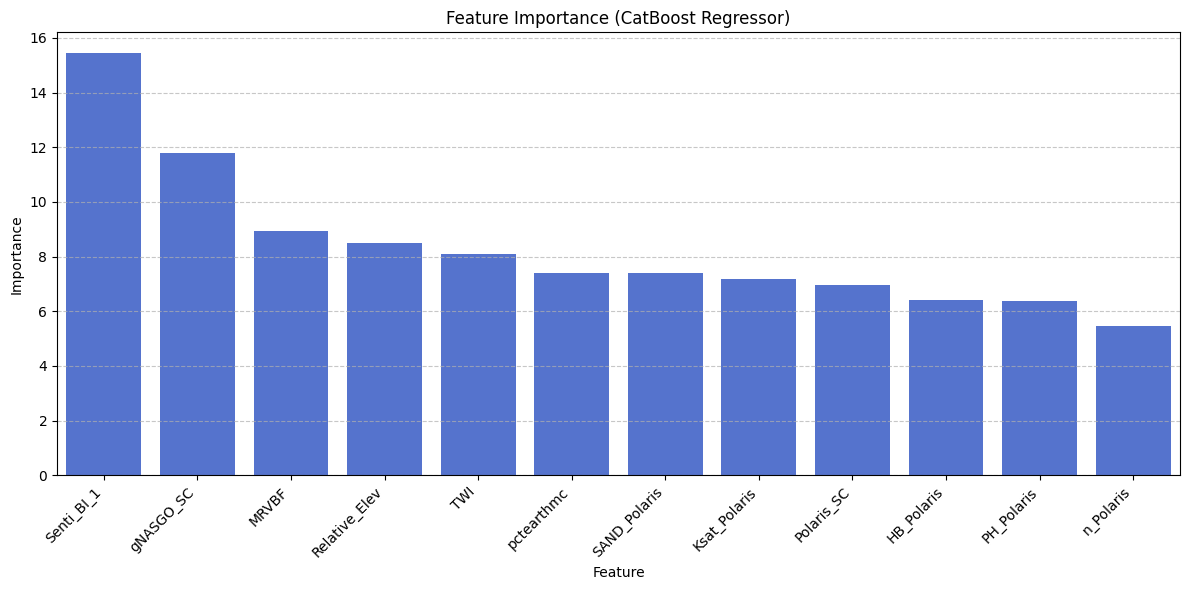

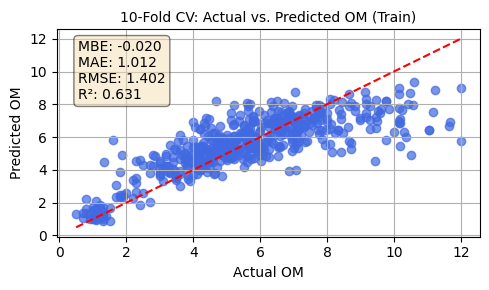

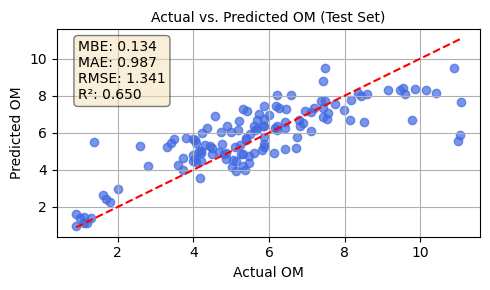

In [ ]:
# Install the catboost library
!pip install catboost

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFE
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# === Step 1: Filter OM > 12 and drop NaNs ===
df_filtered = df_m[df_m['OM'] <= 12]
X = df_filtered.drop(columns=['OM', 'SAMPLEDATE', 'lati', 'long', 'Planet_BI_1'
                              ])
y = df_filtered['OM']
X = X.dropna()
y = y[X.index]
X = X[y.notna()]
y = y.dropna()

# === Step 2: Train-test split ===
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# === Step 3: Standardization ===
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_full)
X_test_scaled = scaler.transform(X_test)

# === Step 4: RFE Feature Selection ===
num_features_to_select = int(0.40 * X.shape[1])
cat_base = CatBoostRegressor(verbose=0, random_state=42)
rfe = RFE(estimator=cat_base, n_features_to_select=num_features_to_select)
rfe.fit(X_train_scaled, y_train_full)

selected_features = X_train_full.columns[rfe.support_]
X_train_selected = X_train_scaled[:, rfe.support_]
X_test_selected = X_test_scaled[:, rfe.support_]

# === Step 5: Grid Search for CatBoost Hyperparameters ===
param_grid = {
    'depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05],
    'iterations': [100, 500,1000]
}
grid_search = GridSearchCV(CatBoostRegressor(verbose=0, random_state=42), param_grid, cv=5, scoring='r2', n_jobs=-1)
grid_search.fit(X_train_selected, y_train_full)
best_model = grid_search.best_estimator_

# === Step 6: 10-Fold Cross Validation on Training Set ===
kf = KFold(n_splits=10, shuffle=True, random_state=42)
train_actual = []
train_predicted = []
train_metrics = {'mbe': [], 'mae': [], 'rmse': [], 'r2': []}

for train_idx, val_idx in kf.split(X_train_selected):
    X_t, X_v = X_train_selected[train_idx], X_train_selected[val_idx]
    y_t, y_v = y_train_full.iloc[train_idx], y_train_full.iloc[val_idx]
    best_model.fit(X_t, y_t, verbose=0)
    y_val_pred = best_model.predict(X_v)

    train_actual.extend(y_v)
    train_predicted.extend(y_val_pred)
    train_metrics['mbe'].append(np.mean(y_val_pred - y_v))
    train_metrics['mae'].append(mean_absolute_error(y_v, y_val_pred))
    train_metrics['rmse'].append(np.sqrt(mean_squared_error(y_v, y_val_pred)))
    train_metrics['r2'].append(r2_score(y_v, y_val_pred))

# === Step 7: Evaluate on Test Set ===
best_model.fit(X_train_selected, y_train_full, verbose=0)
y_test_pred = best_model.predict(X_test_selected)

test_mbe = np.mean(y_test_pred - y_test)
test_mae = mean_absolute_error(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_r2 = r2_score(y_test, y_test_pred)

# === Step 8: Compute Average Train Metrics ===
train_actual_np = np.array(train_actual)
train_predicted_np = np.array(train_predicted)

train_mbe = np.mean(train_predicted_np - train_actual_np)
train_mae = mean_absolute_error(train_actual_np, train_predicted_np)
train_rmse = np.sqrt(mean_squared_error(train_actual_np, train_predicted_np))
train_r2 = r2_score(train_actual_np, train_predicted_np)

# === Step 9: Print Results ===
print("\nBest Model Parameters:", grid_search.best_params_)
print("\nTrain Set Metrics (10-Fold Cross-Validation):")
print(f"MBE: {train_mbe:.4f}, MAE: {train_mae:.4f}, RMSE: {train_rmse:.4f}, R²: {train_r2:.4f}")
print("\nTest Set Metrics:")
print(f"MBE: {test_mbe:.4f}, MAE: {test_mae:.4f}, RMSE: {test_rmse:.4f}, R²: {test_r2:.4f}")

# === Step 10: Feature Importance Plot ===
feature_importance_df = pd.DataFrame({
    'Feature': selected_features,
    'Importance': best_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x='Feature', y='Importance', data=feature_importance_df, color='royalblue')
plt.title("Feature Importance (CatBoost Regressor)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# === Step 11: Scatter Plot for Training Set ===
min_val = min(train_actual_np.min(), train_predicted_np.min())
max_val = max(train_actual_np.max(), train_predicted_np.max())

plt.figure(figsize=(5, 3))
plt.scatter(train_actual_np, train_predicted_np, color="royalblue", alpha=0.7)
plt.plot([min_val, max_val], [min_val, max_val], color="red", linestyle="--")
plt.xlabel("Actual OM")
plt.ylabel("Predicted OM")
plt.title("10-Fold CV: Actual vs. Predicted OM (Train)", fontsize=10)
plt.grid(True)
textstr = '\n'.join((
    f'MBE: {train_mbe:.3f}',
    f'MAE: {train_mae:.3f}',
    f'RMSE: {train_rmse:.3f}',
    f'R²: {train_r2:.3f}'
))
props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
plt.text(0.05, 0.95, textstr, transform=plt.gca().transAxes, verticalalignment='top', bbox=props)
plt.tight_layout()
plt.show()

# === Step 12: Scatter Plot for Test Set ===
test_actual_np = np.array(y_test)
test_predicted_np = np.array(y_test_pred)

min_val = min(test_actual_np.min(), test_predicted_np.min())
max_val = max(test_actual_np.max(), test_predicted_np.max())

plt.figure(figsize=(5, 3))
plt.scatter(test_actual_np, test_predicted_np, color="royalblue", alpha=0.7)
plt.plot([min_val, max_val], [min_val, max_val], color="red", linestyle="--")
plt.xlabel("Actual OM")
plt.ylabel("Predicted OM")
plt.title("Actual vs. Predicted OM (Test Set)", fontsize=10)
plt.grid(True)
textstr = '\n'.join((
    f'MBE: {test_mbe:.3f}',
    f'MAE: {test_mae:.3f}',
    f'RMSE: {test_rmse:.3f}',
    f'R²: {test_r2:.3f}'
))
plt.text(0.05, 0.95, textstr, transform=plt.gca().transAxes, verticalalignment='top', bbox=props)
plt.tight_layout()
plt.show()


In [ ]:
print("Test OM Min/Max:", y_test.min(), y_test.max())


Test OM Min/Max: 0.9 11.07


In [ ]:
print("Train OM Mean:", y_train_full.mean())
print("Test OM Mean:", y_test.mean())
print("Test Predictions Mean:", y_test_pred.mean())


Train OM Mean: 5.580153256704981
Test OM Mean: 5.630534351145037
Test Predictions Mean: 5.764539369667404


In [ ]:
field_df[selected_features].describe()


,Senti_BI_1,gNASGO_SC,MRVBF,Relative_Elev,TWI,SAND_Polaris,PH_Polaris,pctearthmc,Ksat_Polaris,HB_Polaris,n_Polaris,Polaris_SC
count,677.000000,655.000000,676.000000,677.000000,677.000000,677.000000,677.000000,676.000000,677.000000,677.000000,677.000000,677.000000
mean,1491.133524,7210.433826,3.402267,3.545706,16.172145,32.477698,6.698119,83.348026,0.133886,0.401473,1.300351,0.605617
std,205.456508,2623.501549,2.113956,2.377789,74.593290,13.347213,0.404208,9.603001,0.279063,0.099825,0.042655,0.199406
min,1043.605768,405.203125,0.018935,-0.000489,2.440364,6.365234,5.442967,0.000000,-0.323459,0.103433,1.226248,-0.235830
25%,1335.823716,5838.890625,1.703362,1.790000,4.709808,26.241714,6.364072,81.250000,-0.025279,0.342352,1.275073,0.551832
50%,1483.612146,7476.000000,2.816594,3.249994,6.571179,29.516636,6.726035,85.000000,0.075439,0.394098,1.289522,0.676973
75%,1602.832805,8380.242188,4.872082,4.760004,9.426539,35.828461,7.010039,85.000000,0.199133,0.474524,1.310989,0.708641
max,2130.828243,24658.000000,8.676432,14.923537,1136.502630,88.329582,7.738206,100.000000,1.352269,0.716026,1.503931,1.660093


In [ ]:
# Save the trained model to a file
best_model.save_model("catboost_model.cbm")


In [ ]:
test_results_df = pd.DataFrame({
    'Actual_OM': y_test,
    'Predicted_OM': y_test_pred
})

test_results_df.to_csv("test_actual_vs_predicted.csv", index=False)


In [ ]:
import pandas as pd

# === Training Set ===
# y_train_full: original training labels (from train_test_split)
# train_predicted_np: predictions from 10-fold CV
# y_train_full.index: original index from df_filtered

train_results_df = pd.DataFrame({
    "Index": y_train_full.index,
    "Actual_OM": y_train_full.values,
    "Predicted_OM": train_predicted_np
}).sort_values("Index")

# Optional: merge with full input features for GIS or analysis
train_full = df_filtered.loc[train_results_df["Index"]].copy()
train_full["Actual_OM"] = train_results_df["Actual_OM"].values
train_full["Predicted_OM"] = train_results_df["Predicted_OM"].values

# Save training predictions
train_full.to_csv("train_actual_vs_predicted_aligned.csv", index=False)

# === Test Set ===
test_results_df = pd.DataFrame({
    "Index": y_test.index,
    "Actual_OM": y_test.values,
    "Predicted_OM": y_test_pred
}).sort_values("Index")

# Merge with input features
test_full = df_filtered.loc[test_results_df["Index"]].copy()
test_full["Actual_OM"] = test_results_df["Actual_OM"].values
test_full["Predicted_OM"] = test_results_df["Predicted_OM"].values

# Save test predictions
test_full.to_csv("test_actual_vs_predicted_aligned.csv", index=False)


In [ ]:
# Align predictions with original training indices
train_pred_df = pd.DataFrame({
    "Index": y_train_full.index,
    "Actual_OM": y_train_full.values,
    "Predicted_OM": train_predicted_np
}).set_index("Index").sort_index()

# Join with input data for these rows
train_input_df = df_filtered.loc[y_train_full.index]
train_result_df = train_input_df.copy()
train_result_df["Actual_OM"] = train_pred_df["Actual_OM"]
train_result_df["Predicted_OM"] = train_pred_df["Predicted_OM"]

# Save
train_result_df.to_csv("train_cv_predictions_aligned.csv", index=False)


In [ ]:
!pip install catboost

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import CatBoostRegressor
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFE
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# === Load your dataset ===
df_m = pd.read_csv("/content/cleaned_file_OM_withoutfield_1.csv")

# === Step 1: Filter OM > 12 and drop NaNs ===
df_filtered = df_m[df_m['OM'] <= 12]
X = df_filtered.drop(columns=['OM', 'SAMPLEDATE', 'lati', 'long', 'Planet_BI_1'], errors='ignore')
y = df_filtered['OM']
X = X.dropna()
y = y[X.index]
X = X[y.notna()]
y = y.dropna()

# === Step 2: Standardize ===
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# === Step 3: RFE Feature Selection ===
num_features_to_select = int(0.40 * X.shape[1])
cat_base = CatBoostRegressor(verbose=0, random_state=42)
rfe = RFE(estimator=cat_base, n_features_to_select=num_features_to_select)
rfe.fit(X_scaled, y)
selected_features = X.columns[rfe.support_]
X_selected = X_scaled[:, rfe.support_]

# === Step 4: Hyperparameter Tuning ===
param_grid = {
    'depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05],
    'iterations': [100, 500, 1000]
}
grid_search = GridSearchCV(CatBoostRegressor(verbose=0, random_state=42), param_grid, cv=5, scoring='r2', n_jobs=-1)
grid_search.fit(X_selected, y)
best_model = grid_search.best_estimator_

# === Step 5: 10-Fold CV Prediction for Whole Dataset ===
kf = KFold(n_splits=10, shuffle=True, random_state=42)
all_actual = np.zeros_like(y)
all_predicted = np.zeros_like(y)

metrics = {'mbe': [], 'mae': [], 'rmse': [], 'r2': []}

for train_idx, val_idx in kf.split(X_selected):
    X_t, X_v = X_selected[train_idx], X_selected[val_idx]
    y_t, y_v = y.iloc[train_idx], y.iloc[val_idx]
    best_model.fit(X_t, y_t, verbose=0)
    y_val_pred = best_model.predict(X_v)

    all_actual[val_idx] = y_v
    all_predicted[val_idx] = y_val_pred

    metrics['mbe'].append(np.mean(y_val_pred - y_v))
    metrics['mae'].append(mean_absolute_error(y_v, y_val_pred))
    metrics['rmse'].append(np.sqrt(mean_squared_error(y_v, y_val_pred)))
    metrics['r2'].append(r2_score(y_v, y_val_pred))


# === Save predictions with alignment ===
# Create a Series for the predictions using the index from the original 'y' after dropping NaNs
predicted_series = pd.Series(all_predicted, index=y.index)

# Create the result DataFrame from the original df_filtered
df_result = df_filtered.copy()

# Assign the predicted values, aligning by index.
# Rows in df_filtered that were NOT in 'y' (because of NaN removal) will get NaN.
df_result['Predicted_OM'] = predicted_series

# Save to CSV
df_result.to_csv("OM_10Fold_CV_Predictions.csv", index=False)

# === Step 7: Print averaged metrics ===
print("Averaged Metrics:")
for k, v in metrics.items():
    print(f"{k.upper()}: {np.mean(v):.4f}")



Averaged Metrics:
MBE: -0.0182
MAE: 1.0218
RMSE: 1.3934
R2: 0.6153


In [ ]:
# === Step 6: Print averaged metrics ===
print("Averaged Metrics (10-Fold CV):")
print(f"MBE : {np.mean(metrics['mbe']):.4f}")
print(f"MAE : {np.mean(metrics['mae']):.4f}")
print(f"RMSE: {np.mean(metrics['rmse']):.4f}")
print(f"R²  : {np.mean(metrics['r2']):.4f}")

Averaged Metrics (10-Fold CV):
MBE : -0.0182
MAE : 1.0218
RMSE: 1.3934
R²  : 0.6153


In [ ]:
# === TRAINING SCRIPT ===
import numpy as np
import pandas as pd
import joblib
from catboost import CatBoostRegressor
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFE
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# === Step 1: Load and clean training data ===
df = pd.read_csv("/content/cleaned_file_OM_withoutfield_21.csv")
df = df[df['OM'] <= 12].dropna(subset=['OM'])

X = df.drop(columns=['OM', 'SAMPLEDATE', 'lati', 'long', 'Planet_BI_1'], errors='ignore')
y = df['OM']

X = X.dropna()
y = y.loc[X.index]

# === Step 2: Scale all features ===
scaler_full = StandardScaler()
X_scaled_full = scaler_full.fit_transform(X)

# === Step 3: Feature Selection (top 40%) ===
num_features = int(0.4 * X.shape[1])
rfe = RFE(estimator=CatBoostRegressor(verbose=0, random_state=42), n_features_to_select=num_features)
rfe.fit(X_scaled_full, y)

selected_features = X.columns[rfe.support_]
X_selected = X[selected_features]  # raw features after selection

# === Step 4: Scale only selected features ===
scaler = StandardScaler()
X_selected_scaled = scaler.fit_transform(X_selected)

# === Step 5: Train model with GridSearchCV ===
param_grid = {
    'depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05],
    'iterations': [100, 500, 1000]
}
grid_search = GridSearchCV(CatBoostRegressor(verbose=0, random_state=42), param_grid, cv=5, scoring='r2', n_jobs=-1)
grid_search.fit(X_selected_scaled, y)
best_model = grid_search.best_estimator_

# === Step 6: Evaluate with 10-fold CV ===
kf = KFold(n_splits=10, shuffle=True, random_state=42)
metrics = {'mae': [], 'rmse': [], 'r2': []}

for train_idx, val_idx in kf.split(X_selected_scaled):
    X_t, X_v = X_selected_scaled[train_idx], X_selected_scaled[val_idx]
    y_t, y_v = y.iloc[train_idx], y.iloc[val_idx]
    best_model.fit(X_t, y_t)
    y_pred = best_model.predict(X_v)

    metrics['mae'].append(mean_absolute_error(y_v, y_pred))
    metrics['rmse'].append(np.sqrt(mean_squared_error(y_v, y_pred)))
    metrics['r2'].append(r2_score(y_v, y_pred))

print("=== 10-Fold Train Metrics ===")
print(f"MAE: {np.mean(metrics['mae']):.4f}")
print(f"RMSE: {np.mean(metrics['rmse']):.4f}")
print(f"R²: {np.mean(metrics['r2']):.4f}")

# === Step 7: Save model artifacts ===
joblib.dump(best_model, "best_catboost_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(list(selected_features), "selected_features.pkl")


=== 10-Fold Train Metrics ===
MAE: 1.0218
RMSE: 1.3934
R²: 0.6153


['selected_features.pkl']

One_Field_left_train_withmetrices

In [ ]:
import numpy as np
import pandas as pd
import joblib
from catboost import CatBoostRegressor
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFE
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# === Step 1: Load and clean training data ===
df = pd.read_csv("/content/cleaned_file_OM_withoutfield_1.csv")
df = df[df['OM'] <= 12].dropna(subset=['OM'])

X = df.drop(columns=['OM', 'SAMPLEDATE', 'lati', 'long', 'Planet_BI_1'], errors='ignore')
y = df['OM']

X = X.dropna()
y = y.loc[X.index]

# === Step 2: Scale all features ===
scaler_full = StandardScaler()
X_scaled_full = scaler_full.fit_transform(X)

# === Step 3: Feature Selection (top 40%) ===
num_features = int(0.4 * X.shape[1])
rfe = RFE(estimator=CatBoostRegressor(verbose=0, random_state=42), n_features_to_select=num_features)
rfe.fit(X_scaled_full, y)

selected_features = X.columns[rfe.support_]
X_selected = X[selected_features]

# === Step 4: Scale selected features ===
scaler = StandardScaler()
X_selected_scaled = scaler.fit_transform(X_selected)

# === Step 5: Train model with GridSearch ===
param_grid = {
    'depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05],
    'iterations': [100, 500, ]
}
grid_search = GridSearchCV(CatBoostRegressor(verbose=0, random_state=42), param_grid, cv=5, scoring='r2', n_jobs=-1)
grid_search.fit(X_selected_scaled, y)
best_model = grid_search.best_estimator_

# === Step 6: Evaluate with 10-fold CV ===
kf = KFold(n_splits=10, shuffle=True, random_state=42)
metrics = {'mbe': [], 'mae': [], 'rmse': [], 'r2': []}

print("\n=== Per Fold Metrics ===")
for i, (train_idx, val_idx) in enumerate(kf.split(X_selected_scaled), 1):
    X_t, X_v = X_selected_scaled[train_idx], X_selected_scaled[val_idx]
    y_t, y_v = y.iloc[train_idx], y.iloc[val_idx]
    best_model.fit(X_t, y_t)
    y_pred = best_model.predict(X_v)

    mbe = np.mean(y_pred - y_v)
    mae = mean_absolute_error(y_v, y_pred)
    rmse = np.sqrt(mean_squared_error(y_v, y_pred))
    r2 = r2_score(y_v, y_pred)

    metrics['mbe'].append(mbe)
    metrics['mae'].append(mae)
    metrics['rmse'].append(rmse)
    metrics['r2'].append(r2)

    print(f"Fold {i} → MBE: {mbe:.4f}, MAE: {mae:.4f}, RMSE: {rmse:.4f}, R²: {r2:.4f}")

# === Final Average Metrics ===
print("\n=== Average 10-Fold Train Metrics ===")
print(f"MBE:  {np.mean(metrics['mbe']):.4f}")
print(f"MAE:  {np.mean(metrics['mae']):.4f}")
print(f"RMSE: {np.mean(metrics['rmse']):.4f}")
print(f"R²:   {np.mean(metrics['r2']):.4f}")

# === Step 7: Save model artifacts ===
joblib.dump(best_model, "best_catboost_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(list(selected_features), "selected_features.pkl")



=== Per Fold Metrics ===
Fold 1 → MBE: 0.1996, MAE: 1.1311, RMSE: 1.5041, R²: 0.5003
Fold 2 → MBE: -0.1770, MAE: 1.0460, RMSE: 1.3996, R²: 0.6543
Fold 3 → MBE: -0.2592, MAE: 0.9133, RMSE: 1.3104, R²: 0.6571
Fold 4 → MBE: -0.2892, MAE: 1.1799, RMSE: 1.6605, R²: 0.5865
Fold 5 → MBE: 0.3778, MAE: 1.0222, RMSE: 1.3110, R²: 0.6149
Fold 6 → MBE: -0.0314, MAE: 0.9404, RMSE: 1.2231, R²: 0.7021
Fold 7 → MBE: -0.0366, MAE: 0.7880, RMSE: 1.0623, R²: 0.7805
Fold 8 → MBE: 0.4335, MAE: 1.0194, RMSE: 1.4196, R²: 0.5264
Fold 9 → MBE: -0.3993, MAE: 1.1000, RMSE: 1.6296, R²: 0.5998
Fold 10 → MBE: -0.0005, MAE: 1.0776, RMSE: 1.4141, R²: 0.5308

=== Average 10-Fold Train Metrics ===
MBE:  -0.0182
MAE:  1.0218
RMSE: 1.3934
R²:   0.6153


['selected_features.pkl']

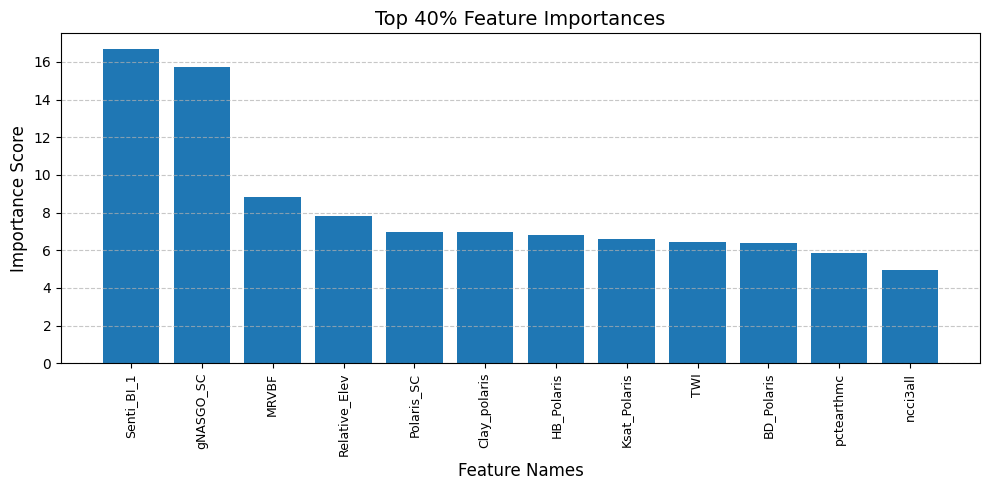

In [ ]:
# Step 8: Feature Importance Plot
importances = best_model.feature_importances_
sorted_idx = np.argsort(importances)[::-1]

# Plotting the feature importances
plt.figure(figsize=(10, 5))
plt.title("Top 40% Feature Importances", fontsize=14)
plt.bar(range(len(selected_features)), importances[sorted_idx])
plt.xticks(
    ticks=range(len(selected_features)),
    labels=np.array(selected_features)[sorted_idx],
    rotation=90,
    fontsize=9
)
plt.ylabel("Importance Score", fontsize=12)
plt.xlabel("Feature Names", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


🔍 Features used for prediction:
 - Relative_Elev
 - Polaris_SC
 - gNASGO_SC
 - MRVBF
 - TWI
 - Clay_polaris
 - BD_Polaris
 - pctearthmc
 - ncci3all
 - HB_Polaris
 - Ksat_Polaris
 - Senti_BI_1

📊 Test Set Metrics:
MAE:  1.0957
RMSE: 1.4799
R²:   0.4296


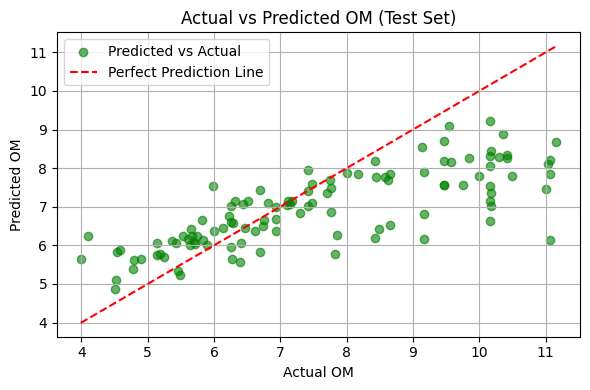

In [ ]:
# === TEST SCRIPT ===
import numpy as np
import pandas as pd
import joblib
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

# === Load test data ===
df_test = pd.read_csv("/content/Antho_Test_1_field.csv")
df_test = df_test.dropna(subset=['OM'])

# === Load model artifacts ===
model = joblib.load("/content/best_catboost_model.pkl")
scaler = joblib.load("/content/scaler.pkl")
selected_features = joblib.load("/content/selected_features.pkl")

# === Display selected features ===
print("🔍 Features used for prediction:")
for feature in selected_features:
    print(f" - {feature}")

# === Prepare test features ===
X_test_raw = df_test.drop(columns=['OM', 'SAMPLEDATE', 'lati', 'long', 'Planet_BI_1'], errors='ignore')
y_test = df_test['OM']

# Add missing columns and maintain order
for col in selected_features:
    if col not in X_test_raw.columns:
        X_test_raw[col] = 0

X_test_final = X_test_raw[selected_features]
X_test_final = X_test_final.fillna(0)

# === Scale test data ===
X_test_scaled = scaler.transform(X_test_final)

# === Predict and evaluate ===
y_pred = model.predict(X_test_scaled)

print("\n📊 Test Set Metrics:")
print(f"MAE:  {mean_absolute_error(y_test, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")
print(f"R²:   {r2_score(y_test, y_pred):.4f}")

# === Plot Actual vs Predicted with perfect-fit line ===
plt.figure(figsize=(6, 4))
plt.scatter(y_test, y_pred, alpha=0.6, color="green", label="Predicted vs Actual")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label="Perfect Prediction Line")
plt.title("Actual vs Predicted OM (Test Set)")
plt.xlabel("Actual OM")
plt.ylabel("Predicted OM")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


After_Pretrained_to_test_here

TRAIN AND TEST DIFFERENT CSV FILE, CAT BOOST

In [ ]:
!pip install catboost
import pandas as pd
import matplotlib.pyplot as plt
from catboost import CatBoostRegressor

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 9.9 MB/s eta 0:00:00


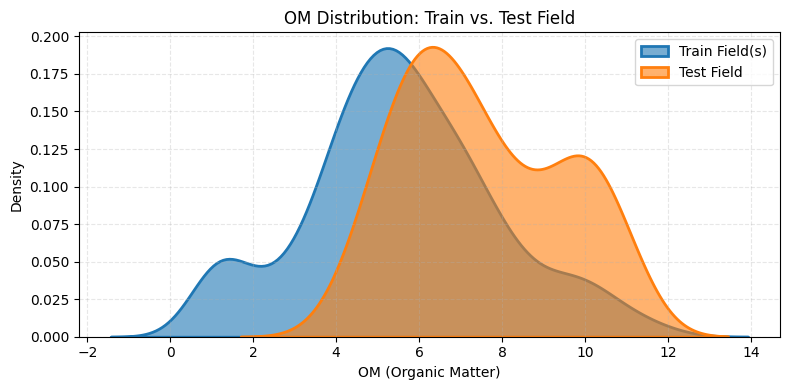

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming df_train and df_test are already loaded and cleaned

plt.figure(figsize=(8, 4))
sns.kdeplot(df_train['OM'], label='Train Field(s)', fill=True, alpha=0.6, linewidth=2)
sns.kdeplot(df_test['OM'], label='Test Field', fill=True, alpha=0.6, linewidth=2)

plt.title('OM Distribution: Train vs. Test Field')
plt.xlabel('OM (Organic Matter)')
plt.ylabel('Density')
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


Random_Forest

Fitting 3 folds for each of 96 candidates, totalling 288 fits

=== Per Fold Metrics ===
Fold 1 → MBE: 0.1928, MAE: 1.1555, RMSE: 1.5479, R²: 0.4708
Fold 2 → MBE: -0.1797, MAE: 1.0544, RMSE: 1.4162, R²: 0.6460
Fold 3 → MBE: -0.2702, MAE: 0.8614, RMSE: 1.2557, R²: 0.6851
Fold 4 → MBE: -0.2784, MAE: 1.2042, RMSE: 1.6745, R²: 0.5795
Fold 5 → MBE: 0.5047, MAE: 1.0042, RMSE: 1.3190, R²: 0.6102
Fold 6 → MBE: 0.0084, MAE: 0.8766, RMSE: 1.1726, R²: 0.7262
Fold 7 → MBE: -0.0203, MAE: 0.7854, RMSE: 1.0646, R²: 0.7796
Fold 8 → MBE: 0.4451, MAE: 1.0048, RMSE: 1.4706, R²: 0.4917
Fold 9 → MBE: -0.3162, MAE: 1.1246, RMSE: 1.6246, R²: 0.6023
Fold 10 → MBE: -0.0379, MAE: 1.1620, RMSE: 1.6019, R²: 0.3979

=== Average 10-Fold Train Metrics ===
MBE:  0.0048
MAE:  1.0233
RMSE: 1.4148
R²:   0.5989


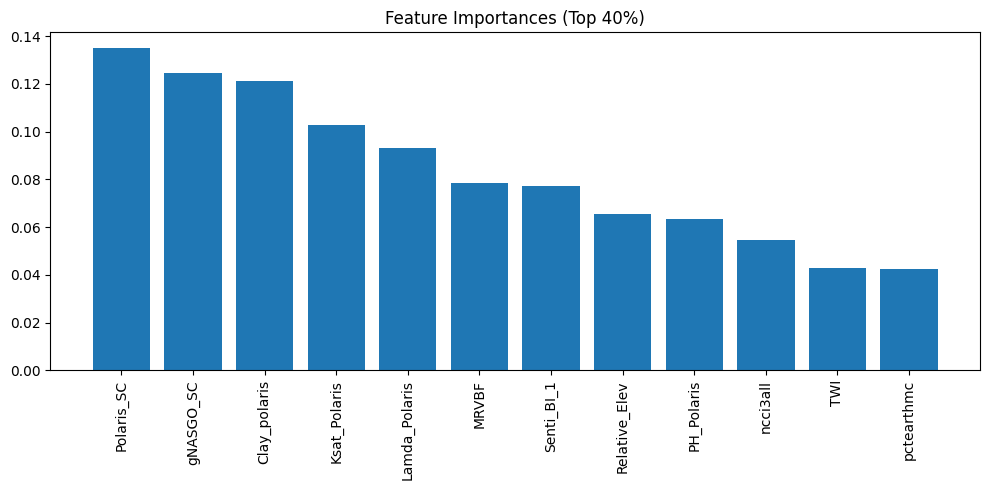

In [ ]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFE
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# === Step 1: Load and clean training data ===
df = pd.read_csv("cleaned_file_OM_withoutfield_1.csv")
df = df[df['OM'] <= 12].dropna(subset=['OM'])

X = df.drop(columns=['OM', 'SAMPLEDATE', 'lati', 'long', 'Planet_BI_1'], errors='ignore')
y = df['OM']

X = X.dropna()
y = y.loc[X.index]

# === Step 2: Scale all features ===
scaler_full = StandardScaler()
X_scaled_full = scaler_full.fit_transform(X)

# === Step 3: Feature Selection (top 40%) ===
num_features = int(0.4 * X.shape[1])
rfe = RFE(estimator=RandomForestRegressor(n_estimators=100, random_state=42), n_features_to_select=num_features)
rfe.fit(X_scaled_full, y)
selected_features = X.columns[rfe.support_]
X_selected = X[selected_features]

# === Step 4: Scale selected features ===
scaler = StandardScaler()
X_selected_scaled = scaler.fit_transform(X_selected)

# === Step 5: Hyperparameter Tuning with GridSearch ===
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2'],
    'bootstrap': [True, False]
}

grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_selected_scaled, y)
best_model = grid_search.best_estimator_

# === Step 6: Evaluate with 10-fold CV ===
kf = KFold(n_splits=10, shuffle=True, random_state=42)
metrics = {'mbe': [], 'mae': [], 'rmse': [], 'r2': []}

print("\n=== Per Fold Metrics ===")
for i, (train_idx, val_idx) in enumerate(kf.split(X_selected_scaled), 1):
    X_t, X_v = X_selected_scaled[train_idx], X_selected_scaled[val_idx]
    y_t, y_v = y.iloc[train_idx], y.iloc[val_idx]
    best_model.fit(X_t, y_t)
    y_pred = best_model.predict(X_v)

    mbe = np.mean(y_pred - y_v)
    mae = mean_absolute_error(y_v, y_pred)
    rmse = np.sqrt(mean_squared_error(y_v, y_pred))
    r2 = r2_score(y_v, y_pred)

    metrics['mbe'].append(mbe)
    metrics['mae'].append(mae)
    metrics['rmse'].append(rmse)
    metrics['r2'].append(r2)

    print(f"Fold {i} → MBE: {mbe:.4f}, MAE: {mae:.4f}, RMSE: {rmse:.4f}, R²: {r2:.4f}")

# === Final Average Metrics ===
print("\n=== Average 10-Fold Train Metrics ===")
print(f"MBE:  {np.mean(metrics['mbe']):.4f}")
print(f"MAE:  {np.mean(metrics['mae']):.4f}")
print(f"RMSE: {np.mean(metrics['rmse']):.4f}")
print(f"R²:   {np.mean(metrics['r2']):.4f}")

# === Step 7: Save model artifacts ===
joblib.dump(best_model, "best_rf_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(list(selected_features), "selected_features.pkl")

# === Step 8: Feature Importance Plot ===
importances = best_model.feature_importances_
sorted_idx = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 5))
plt.title("Feature Importances (Top 40%)")
plt.bar(range(len(selected_features)), importances[sorted_idx])
plt.xticks(range(len(selected_features)), np.array(selected_features)[sorted_idx], rotation=90)
plt.tight_layout()
plt.show()


test

🔍 Features used for prediction:
 - Relative_Elev
 - Polaris_SC
 - gNASGO_SC
 - MRVBF
 - TWI
 - Clay_polaris
 - PH_Polaris
 - pctearthmc
 - ncci3all
 - Ksat_Polaris
 - Lamda_Polaris
 - Senti_BI_1

📊 Test Set Metrics (Random Forest):
MAE:  0.7890
RMSE: 1.2067
R²:   0.6207


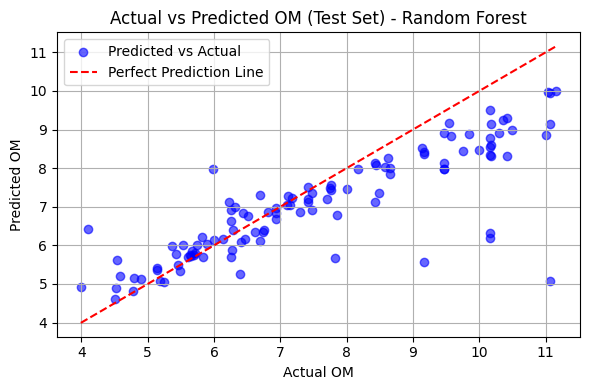

In [ ]:
# === TEST SCRIPT (Random Forest) ===
import numpy as np
import pandas as pd
import joblib
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

# === Load test data ===
df_test = pd.read_csv("/content/Antho_Test_1_field.csv")
df_test = df_test.dropna(subset=['OM'])

# === Load model artifacts ===
model = joblib.load("/content/best_rf_model.pkl")  # Random Forest model
scaler = joblib.load("/content/scaler.pkl")
selected_features = joblib.load("/content/selected_features.pkl")

# === Display selected features ===
print("🔍 Features used for prediction:")
for feature in selected_features:
    print(f" - {feature}")

# === Prepare test features ===
X_test_raw = df_test.drop(columns=['OM', 'SAMPLEDATE', 'lati', 'long', 'Planet_BI_1'], errors='ignore')
y_test = df_test['OM']

# Add missing columns and maintain order
for col in selected_features:
    if col not in X_test_raw.columns:
        X_test_raw[col] = 0

X_test_final = X_test_raw[selected_features]
X_test_final = X_test_final.fillna(0)

# === Scale test data ===
X_test_scaled = scaler.transform(X_test_final)

# === Predict and evaluate ===
y_pred = model.predict(X_test_scaled)

print("\n📊 Test Set Metrics (Random Forest):")
print(f"MAE:  {mean_absolute_error(y_test, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")
print(f"R²:   {r2_score(y_test, y_pred):.4f}")

# === Plot Actual vs Predicted with perfect-fit line ===
plt.figure(figsize=(6, 4))
plt.scatter(y_test, y_pred, alpha=0.6, color="blue", label="Predicted vs Actual")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label="Perfect Prediction Line")
plt.title("Actual vs Predicted OM (Test Set) - Random Forest")
plt.xlabel("Actual OM")
plt.ylabel("Predicted OM")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


ET

Fitting 3 folds for each of 48 candidates, totalling 144 fits

✅ Best Hyperparameters:
{'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}

📊 Per Fold Metrics:
Fold 1 → MBE: 0.2428, MAE: 1.2531, RMSE: 1.6698, R²: 0.3841
Fold 2 → MBE: -0.1904, MAE: 1.1065, RMSE: 1.4888, R²: 0.6088
Fold 3 → MBE: -0.2726, MAE: 1.0037, RMSE: 1.3908, R²: 0.6138
Fold 4 → MBE: -0.3484, MAE: 1.3064, RMSE: 1.7825, R²: 0.5235
Fold 5 → MBE: 0.4445, MAE: 1.1304, RMSE: 1.4415, R²: 0.5344
Fold 6 → MBE: -0.0144, MAE: 0.9449, RMSE: 1.2791, R²: 0.6741
Fold 7 → MBE: -0.0435, MAE: 0.9016, RMSE: 1.2416, R²: 0.7002
Fold 8 → MBE: 0.5014, MAE: 1.0885, RMSE: 1.5055, R²: 0.4673
Fold 9 → MBE: -0.3704, MAE: 1.2212, RMSE: 1.7644, R²: 0.5309
Fold 10 → MBE: 0.0509, MAE: 1.2126, RMSE: 1.6155, R²: 0.3876

📌 Average 10-Fold Train Metrics:
MBE:  -0.0000
MAE:  1.1169
RMSE: 1.5180
R²:   0.5425


/tmp/ipython-input-13-3833395938.py:105: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


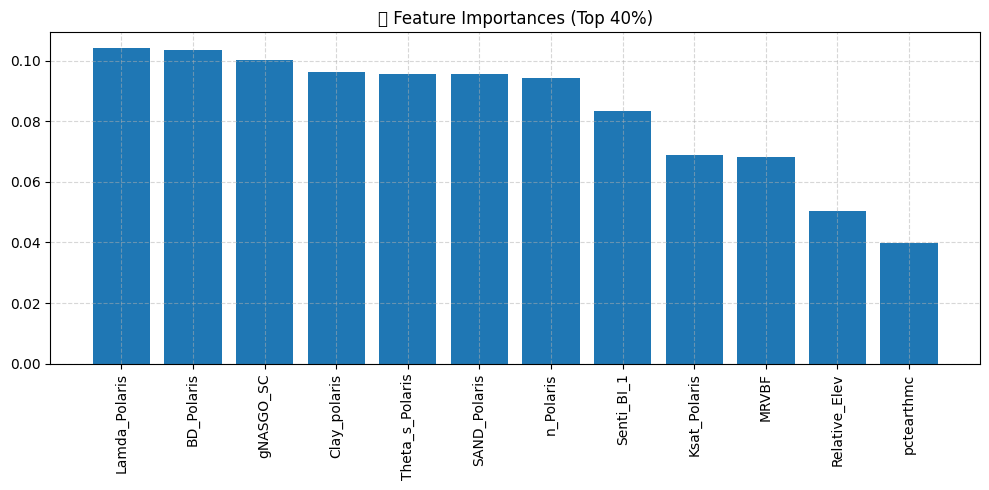

In [ ]:
# === All-in-One Training Script with ExtraTreesRegressor ===
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from sklearn.ensemble import ExtraTreesRegressor
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFE
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# === Step 1: Load and clean data ===
df = pd.read_csv("cleaned_file_OM_withoutfield_1.csv")
df = df[df['OM'] <= 12].dropna(subset=['OM'])

X = df.drop(columns=['OM', 'SAMPLEDATE', 'lati', 'long', 'Planet_BI_1'], errors='ignore')
y = df['OM']
X = X.dropna()
y = y.loc[X.index]

# === Step 2: Scale all features ===
scaler_full = StandardScaler()
X_scaled_full = scaler_full.fit_transform(X)

# === Step 3: Feature Selection (top 40%) ===
num_features = int(0.4 * X.shape[1])
rfe = RFE(estimator=ExtraTreesRegressor(n_estimators=100, random_state=42), n_features_to_select=num_features)
rfe.fit(X_scaled_full, y)

selected_features = X.columns[rfe.support_]
X_selected = X[selected_features]

# === Step 4: Scale selected features ===
scaler = StandardScaler()
X_selected_scaled = scaler.fit_transform(X_selected)

# === Step 5: Hyperparameter Tuning ===
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2']
}

grid_search = GridSearchCV(
    estimator=ExtraTreesRegressor(random_state=42),
    param_grid=param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_selected_scaled, y)
best_model = grid_search.best_estimator_

# === Print best hyperparameters ===
print("\n✅ Best Hyperparameters:")
print(grid_search.best_params_)

# === Step 6: Evaluate with 10-fold CV ===
kf = KFold(n_splits=10, shuffle=True, random_state=42)
metrics = {'mbe': [], 'mae': [], 'rmse': [], 'r2': []}

print("\n📊 Per Fold Metrics:")
for i, (train_idx, val_idx) in enumerate(kf.split(X_selected_scaled), 1):
    X_t, X_v = X_selected_scaled[train_idx], X_selected_scaled[val_idx]
    y_t, y_v = y.iloc[train_idx], y.iloc[val_idx]
    best_model.fit(X_t, y_t)
    y_pred = best_model.predict(X_v)

    mbe = np.mean(y_pred - y_v)
    mae = mean_absolute_error(y_v, y_pred)
    rmse = np.sqrt(mean_squared_error(y_v, y_pred))
    r2 = r2_score(y_v, y_pred)

    metrics['mbe'].append(mbe)
    metrics['mae'].append(mae)
    metrics['rmse'].append(rmse)
    metrics['r2'].append(r2)

    print(f"Fold {i} → MBE: {mbe:.4f}, MAE: {mae:.4f}, RMSE: {rmse:.4f}, R²: {r2:.4f}")

# === Step 7: Average Metrics ===
print("\n📌 Average 10-Fold Train Metrics:")
print(f"MBE:  {np.mean(metrics['mbe']):.4f}")
print(f"MAE:  {np.mean(metrics['mae']):.4f}")
print(f"RMSE: {np.mean(metrics['rmse']):.4f}")
print(f"R²:   {np.mean(metrics['r2']):.4f}")

# === Step 8: Save Model Artifacts ===
joblib.dump(best_model, "best_et_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(list(selected_features), "selected_features.pkl")

# === Step 9: Feature Importance Plot ===
importances = best_model.feature_importances_
sorted_idx = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 5))
plt.title("📈 Feature Importances (Top 40%)")
plt.bar(range(len(selected_features)), importances[sorted_idx])
plt.xticks(range(len(selected_features)), np.array(selected_features)[sorted_idx], rotation=90)
plt.tight_layout()
plt.grid(True, linestyle='--', alpha=0.5)
plt.axhline(y=0, color='black', linewidth=0.5)
plt.show()


TEST_ET

🔍 Features used for prediction:
 - Relative_Elev
 - gNASGO_SC
 - MRVBF
 - Clay_polaris
 - SAND_Polaris
 - BD_Polaris
 - pctearthmc
 - Ksat_Polaris
 - Lamda_Polaris
 - n_Polaris
 - Theta_s_Polaris
 - Senti_BI_1

📊 Test Set Metrics:
MAE:  1.1927
RMSE: 1.6811
R²:   0.2639


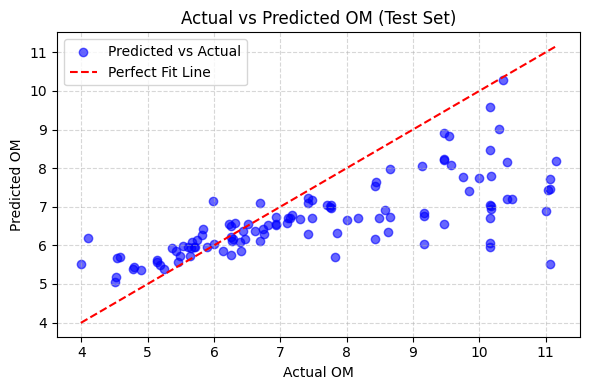

In [ ]:
# === TEST SCRIPT ===
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# === Step 1: Load test data ===
df_test = pd.read_csv("Antho_Test_1_field.csv")
df_test = df_test.dropna(subset=['OM'])

# === Step 2: Load model artifacts ===
model = joblib.load("best_et_model.pkl")
scaler = joblib.load("scaler.pkl")
selected_features = joblib.load("selected_features.pkl")

# === Step 3: Display selected features ===
print("🔍 Features used for prediction:")
for feature in selected_features:
    print(f" - {feature}")

# === Step 4: Prepare test features ===
X_test_raw = df_test.drop(columns=['OM', 'SAMPLEDATE', 'lati', 'long', 'Planet_BI_1'], errors='ignore')
y_test = df_test['OM']

# Add missing columns and maintain order
for col in selected_features:
    if col not in X_test_raw.columns:
        X_test_raw[col] = 0

X_test_final = X_test_raw[selected_features]
X_test_final = X_test_final.fillna(0)

# === Step 5: Scale test features ===
X_test_scaled = scaler.transform(X_test_final)

# === Step 6: Predict and evaluate ===
y_pred = model.predict(X_test_scaled)

print("\n📊 Test Set Metrics:")
print(f"MAE:  {mean_absolute_error(y_test, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")
print(f"R²:   {r2_score(y_test, y_pred):.4f}")

# === Step 7: Plot Actual vs Predicted ===
plt.figure(figsize=(6, 4))
plt.scatter(y_test, y_pred, alpha=0.6, color="blue", label="Predicted vs Actual")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label="Perfect Fit Line")
plt.title("Actual vs Predicted OM (Test Set)")
plt.xlabel("Actual OM")
plt.ylabel("Predicted OM")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


/tmp/ipython-input-16-1796539340.py:51: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0, 1, 0.95])
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


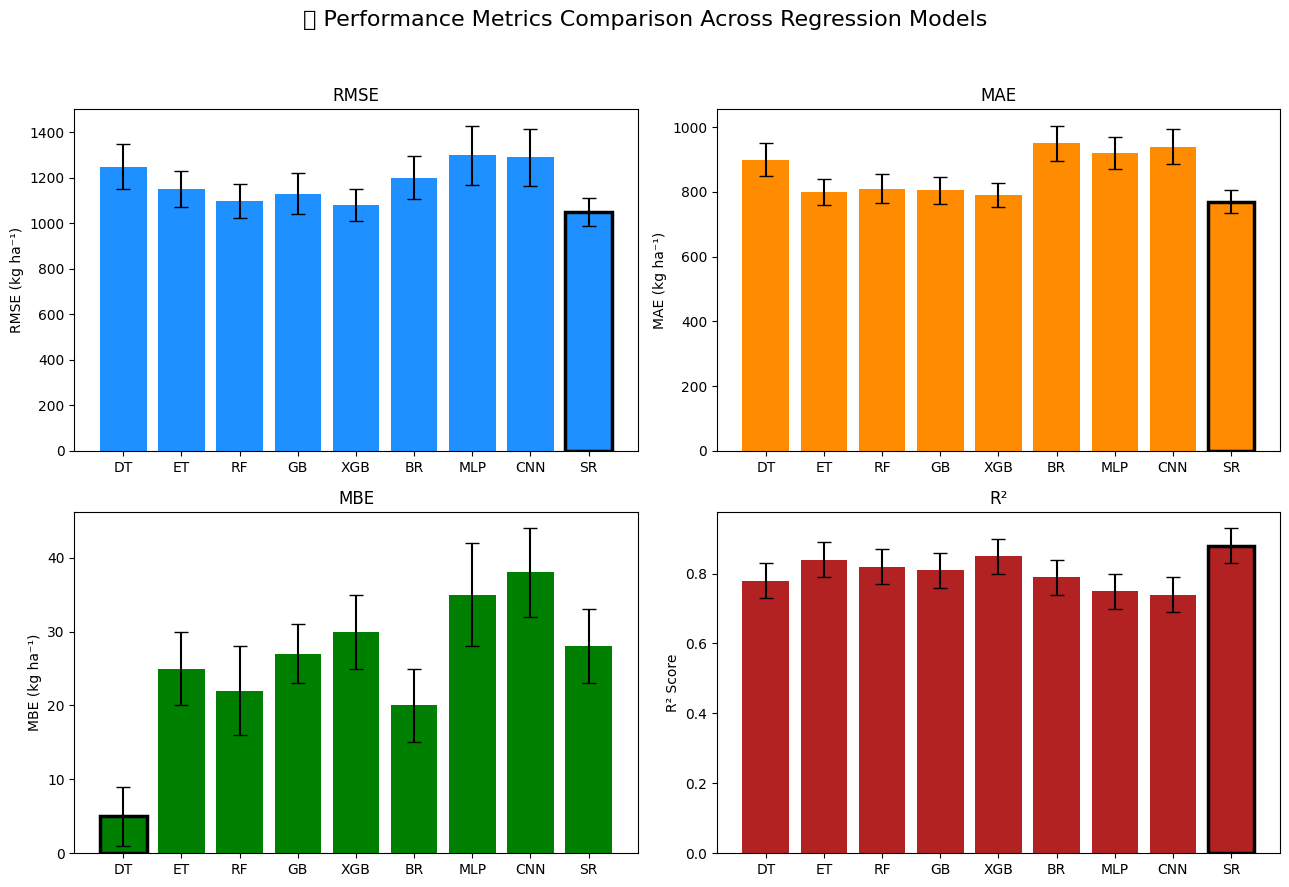

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# === Sample metric values (replace with your actual results) ===
models = ['DT', 'ET', 'RF', 'GB', 'XGB', 'BR', 'MLP', 'CNN', 'SR']

rmse = [1250, 1150, 1100, 1130, 1080, 1200, 1300, 1290, 1050]
mae  = [900, 800, 810, 805, 790, 950, 920, 940, 770]
mbe  = [5, 25, 22, 27, 30, 20, 35, 38, 28]
r2   = [0.78, 0.84, 0.82, 0.81, 0.85, 0.79, 0.75, 0.74, 0.88]

# === Simulated error bars (std devs); replace with actual ones ===
rmse_err = [100, 80, 75, 90, 70, 95, 130, 125, 60]
mae_err  = [50, 40, 45, 42, 38, 55, 50, 53, 35]
mbe_err  = [4, 5, 6, 4, 5, 5, 7, 6, 5]
r2_err   = [0.05] * len(models)

# === Plotting ===
fig, axs = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle('📊 Performance Metrics Comparison Across Regression Models', fontsize=16)

# — RMSE —
axs[0, 0].bar(models, rmse, color='dodgerblue', yerr=rmse_err, capsize=5)
axs[0, 0].set_title("RMSE")
axs[0, 0].set_ylabel("RMSE (kg ha⁻¹)")

# — MAE —
axs[0, 1].bar(models, mae, color='darkorange', yerr=mae_err, capsize=5)
axs[0, 1].set_title("MAE")
axs[0, 1].set_ylabel("MAE (kg ha⁻¹)")

# — MBE —
axs[1, 0].bar(models, mbe, color='green', yerr=mbe_err, capsize=5)
axs[1, 0].set_title("MBE")
axs[1, 0].set_ylabel("MBE (kg ha⁻¹)")

# — R² —
axs[1, 1].bar(models, r2, color='firebrick', yerr=r2_err, capsize=5)
axs[1, 1].set_title("R²")
axs[1, 1].set_ylabel("R² Score")

# === Highlight best model per metric ===
for ax, values, is_higher_better in zip(
    axs.flat, [rmse, mae, mbe, r2], [False, False, False, True]
):
    best_idx = np.argmax(values) if is_higher_better else np.argmin(values)
    ax.bar(models[best_idx], values[best_idx],
           edgecolor='black', linewidth=2.5, fill=False)

# === Final layout adjustments ===
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


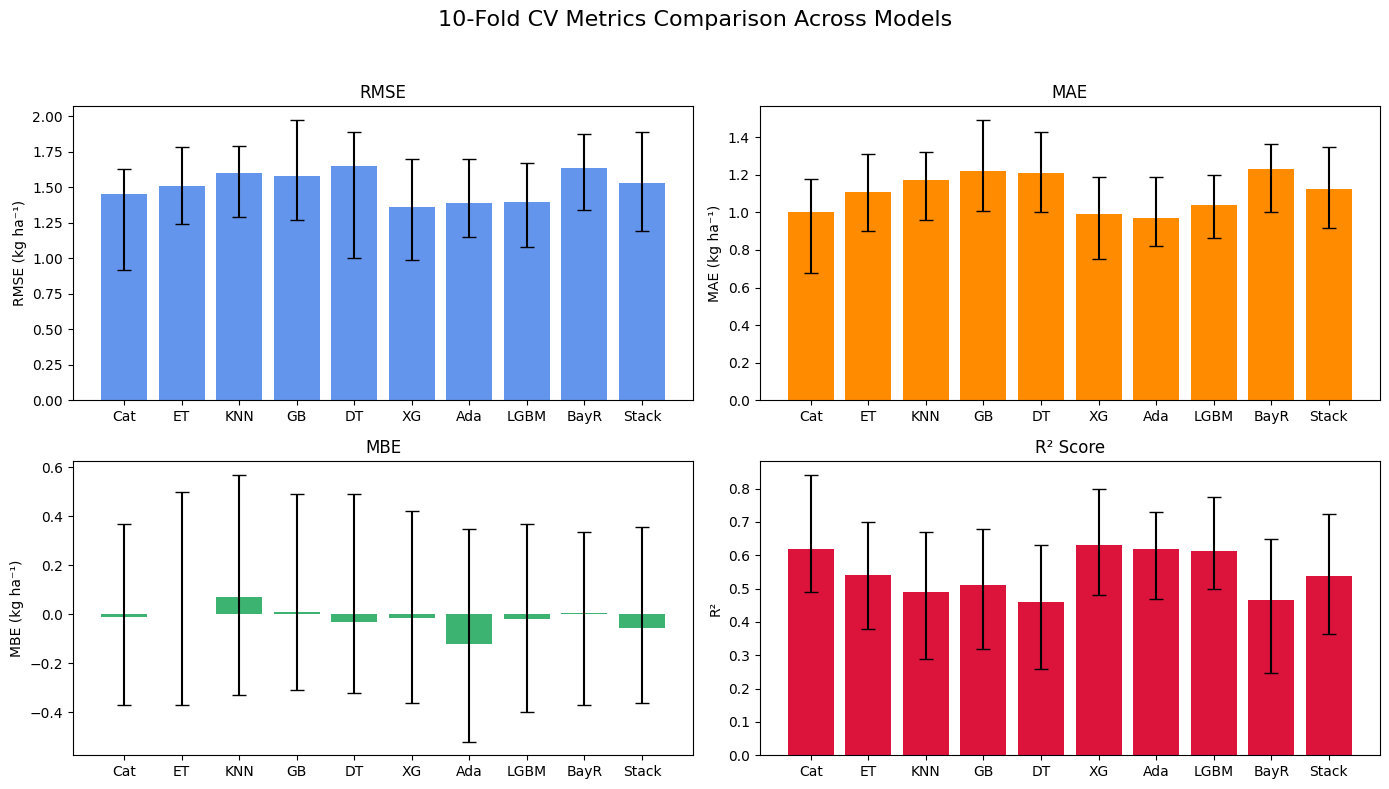


📌 Stacking Metrics Summary (10-Fold CV):
MBE:  Mean = -0.0550, Min = -0.3604, Max = 0.3580
MAE:  Mean = 1.1263, Min = 0.9143, Max = 1.3458
RMSE: Mean = 1.5268, Min = 1.1941, Max = 1.8899
R²:   Mean = 0.5374, Min = 0.3626, Max = 0.7227


In [43]:
import matplotlib.pyplot as plt
import numpy as np

# Model names
models = ['Cat', 'ET', 'KNN', 'GB', 'DT', 'XG', 'Ada', 'LGBM', 'BayR', 'Stack', 'KSVM' ]

# Mean values
rmse = [1.45, 1.51, 1.60, 1.58, 1.65, 1.36, 1.39, 1.3958, 1.6363, 1.5268, 1.636]
mae  = [1.00, 1.11, 1.17, 1.22, 1.21, 0.99, 0.97, 1.0374, 1.2314, 1.1263,]
mbe  = [-0.01, 0.00, 0.07, 0.01, -0.03, -0.014, -0.121, -0.0187, 0.0047, -0.0550,]
r2   = [0.62, 0.54, 0.49, 0.51, 0.46, 0.63, 0.618, 0.6134, 0.4673, 0.5374,]

# Min and Max values for error bars
rmse_min = [0.92, 1.24, 1.29, 1.27, 1.00, 0.99, 1.15, 1.0792, 1.3412, 1.1941,]
rmse_max = [1.63, 1.78, 1.79, 1.97, 1.89, 1.70, 1.70, 1.6724, 1.8763, 1.8899,]

mae_min = [0.68, 0.90, 0.96, 1.01, 1.00, 0.75, 0.82, 0.8649, 1.0019, 0.9143 , ]
mae_max = [1.18, 1.31, 1.32, 1.49, 1.43, 1.19, 1.19, 1.1996, 1.3659, 1.3458 , ]

mbe_min = [-0.37, -0.37, -0.33, -0.31, -0.32, -0.36, -0.52, -0.3972, -0.3711, -0.3604 ,]
mbe_max = [0.37, 0.50, 0.57, 0.49, 0.49, 0.42, 0.35, 0.3679, 0.3360, 0.3580, ]

r2_min = [0.49, 0.38, 0.29, 0.32, 0.26, 0.48, 0.47, 0.4983, 0.2455, 0.3626 ,]
r2_max = [0.84, 0.70, 0.67, 0.68, 0.63, 0.80, 0.73, 0.7735, 0.6502, 0.7227, ]

# Calculate error bars
rmse_err = [np.abs(np.array(rmse) - np.array(rmse_min)), np.abs(np.array(rmse_max) - np.array(rmse))]
mae_err = [np.abs(np.array(mae) - np.array(mae_min)), np.abs(np.array(mae_max) - np.array(mae))]
mbe_err = [np.abs(np.array(mbe) - np.array(mbe_min)), np.abs(np.array(mbe_max) - np.array(mbe))]
r2_err = [np.abs(np.array(r2) - np.array(r2_min)), np.abs(np.array(r2_max) - np.array(r2))]

# Plotting
fig, axs = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('10-Fold CV Metrics Comparison Across Models', fontsize=16)

# RMSE
axs[0, 0].bar(models, rmse, color='cornflowerblue', yerr=rmse_err, capsize=5)
axs[0, 0].set_title("RMSE")
axs[0, 0].set_ylabel("RMSE (kg ha⁻¹)")

# MAE
axs[0, 1].bar(models, mae, color='darkorange', yerr=mae_err, capsize=5)
axs[0, 1].set_title("MAE")
axs[0, 1].set_ylabel("MAE (kg ha⁻¹)")

# MBE
axs[1, 0].bar(models, mbe, color='mediumseagreen', yerr=mbe_err, capsize=5)
axs[1, 0].set_title("MBE")
axs[1, 0].set_ylabel("MBE (kg ha⁻¹)")

# R²
axs[1, 1].bar(models, r2, color='crimson', yerr=r2_err, capsize=5)
axs[1, 1].set_title("R² Score")
axs[1, 1].set_ylabel("R²")

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# 📌 Print Stacking Model Metrics Summary
print("\n📌 Stacking Metrics Summary (10-Fold CV):")
print(f"MBE:  Mean = {mbe[-1]:.4f}, Min = {mbe_min[-1]:.4f}, Max = {mbe_max[-1]:.4f}")
print(f"MAE:  Mean = {mae[-1]:.4f}, Min = {mae_min[-1]:.4f}, Max = {mae_max[-1]:.4f}")
print(f"RMSE: Mean = {rmse[-1]:.4f}, Min = {rmse_min[-1]:.4f}, Max = {rmse_max[-1]:.4f}")
print(f"R²:   Mean = {r2[-1]:.4f}, Min = {r2_min[-1]:.4f}, Max = {r2_max[-1]:.4f}")


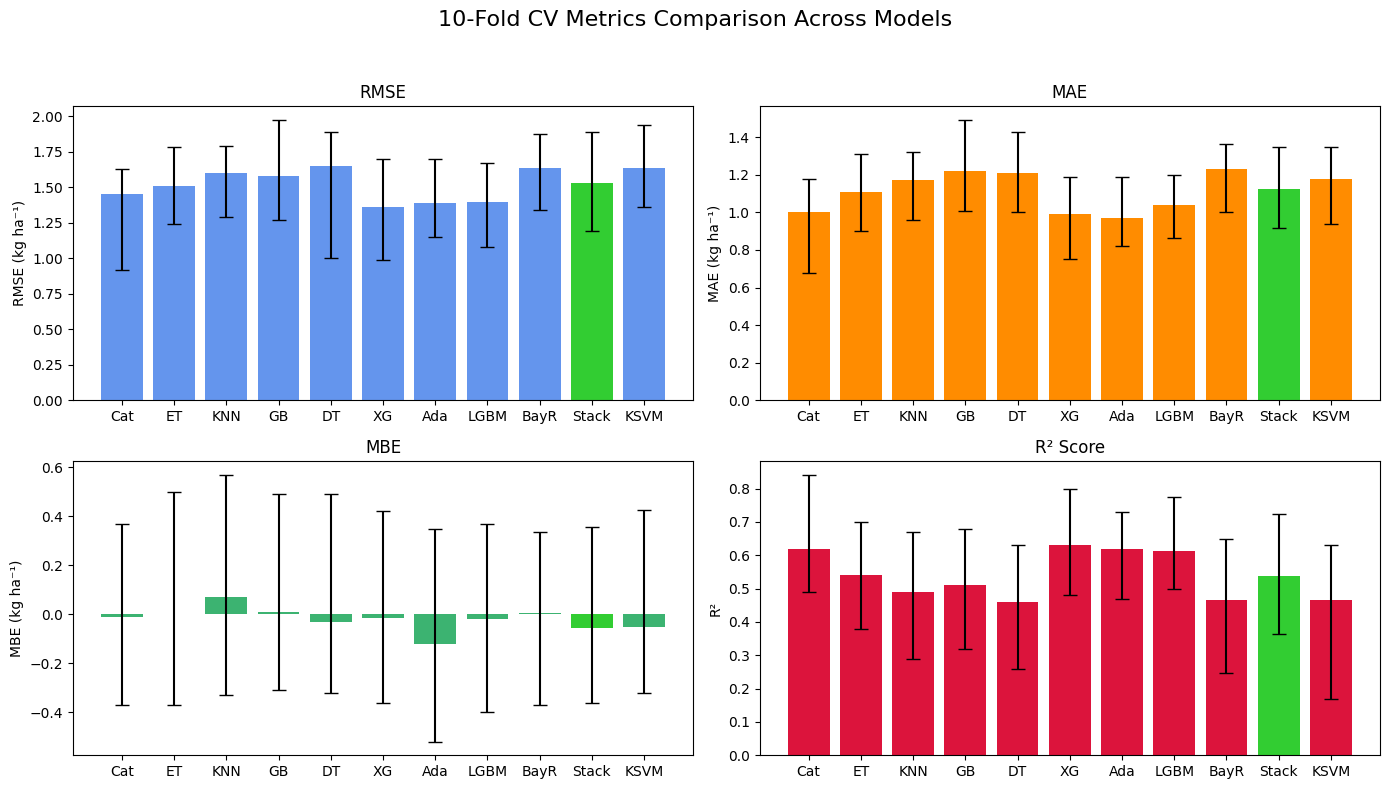


📌 Stacking Metrics Summary (10-Fold CV):
MBE:  Mean = -0.0550, Min = -0.3604, Max = 0.3580
MAE:  Mean = 1.1263, Min = 0.9143, Max = 1.3458
RMSE: Mean = 1.5268, Min = 1.1941, Max = 1.8899
R²:   Mean = 0.5374, Min = 0.3626, Max = 0.7227

📌 KSVM Metrics Summary (10-Fold CV):
MBE:  Mean = -0.0520, Min = -0.3210, Max = 0.4280
MAE:  Mean = 1.1780, Min = 0.9380, Max = 1.3500
RMSE: Mean = 1.6360, Min = 1.3620, Max = 1.9400
R²:   Mean = 0.4650, Min = 0.1700, Max = 0.6300


In [46]:
import matplotlib.pyplot as plt
import numpy as np

# Model names
models = ['Cat', 'ET', 'KNN', 'GB', 'DT', 'XG', 'Ada', 'LGBM', 'BayR', 'Stack', 'KSVM']

# Mean values
rmse = [1.45, 1.51, 1.60, 1.58, 1.65, 1.36, 1.39, 1.3958, 1.6363, 1.5268, 1.636]
mae  = [1.00, 1.11, 1.17, 1.22, 1.21, 0.99, 0.97, 1.0374, 1.2314, 1.1263, 1.178]
mbe  = [-0.01, 0.00, 0.07, 0.01, -0.03, -0.014, -0.121, -0.0187, 0.0047, -0.0550, -0.052]
r2   = [0.62, 0.54, 0.49, 0.51, 0.46, 0.63, 0.618, 0.6134, 0.4673, 0.5374, 0.465]

# Min and Max values for error bars
rmse_min = [0.92, 1.24, 1.29, 1.27, 1.00, 0.99, 1.15, 1.0792, 1.3412, 1.1941, 1.362]
rmse_max = [1.63, 1.78, 1.79, 1.97, 1.89, 1.70, 1.70, 1.6724, 1.8763, 1.8899, 1.94]

mae_min = [0.68, 0.90, 0.96, 1.01, 1.00, 0.75, 0.82, 0.8649, 1.0019, 0.9143, 0.938]
mae_max = [1.18, 1.31, 1.32, 1.49, 1.43, 1.19, 1.19, 1.1996, 1.3659, 1.3458, 1.35]

mbe_min = [-0.37, -0.37, -0.33, -0.31, -0.32, -0.36, -0.52, -0.3972, -0.3711, -0.3604, -0.321]
mbe_max = [0.37, 0.50, 0.57, 0.49, 0.49, 0.42, 0.35, 0.3679, 0.3360, 0.3580, 0.428]

r2_min = [0.49, 0.38, 0.29, 0.32, 0.26, 0.48, 0.47, 0.4983, 0.2455, 0.3626, 0.17]
r2_max = [0.84, 0.70, 0.67, 0.68, 0.63, 0.80, 0.73, 0.7735, 0.6502, 0.7227, 0.63]

# Calculate error bars
rmse_err = [np.abs(np.array(rmse) - np.array(rmse_min)), np.abs(np.array(rmse_max) - np.array(rmse))]
mae_err = [np.abs(np.array(mae) - np.array(mae_min)), np.abs(np.array(mae_max) - np.array(mae))]
mbe_err = [np.abs(np.array(mbe) - np.array(mbe_min)), np.abs(np.array(mbe_max) - np.array(mbe))]
r2_err = [np.abs(np.array(r2) - np.array(r2_min)), np.abs(np.array(r2_max) - np.array(r2))]

# Highlight color (best model: Stack at index 9)
#highlight_idx = 9
#colors_rmse = ['cornflowerblue'] * len(models)
#colors_rmse[highlight_idx] = 'limegreen'

  #colors_mae = ['darkorange'] * len(models)
  #colors_mae[highlight_idx] = 'limegreen'

  #colors_mbe = ['mediumseagreen'] * len(models)
  #colors_mbe[highlight_idx] = 'limegreen'

  #colors_r2 = ['crimson'] * len(models)
  #colors_r2[highlight_idx] = 'limegreen'

# Plotting
fig, axs = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('10-Fold CV Metrics Comparison Across Models', fontsize=16)

axs[0, 0].bar(models, rmse, color=colors_rmse, yerr=rmse_err, capsize=5)
axs[0, 0].set_title("RMSE")
axs[0, 0].set_ylabel("RMSE (kg ha⁻¹)")

axs[0, 1].bar(models, mae, color=colors_mae, yerr=mae_err, capsize=5)
axs[0, 1].set_title("MAE")
axs[0, 1].set_ylabel("MAE (kg ha⁻¹)")

axs[1, 0].bar(models, mbe, color=colors_mbe, yerr=mbe_err, capsize=5)
axs[1, 0].set_title("MBE")
axs[1, 0].set_ylabel("MBE (kg ha⁻¹)")

axs[1, 1].bar(models, r2, color=colors_r2, yerr=r2_err, capsize=5)
axs[1, 1].set_title("R² Score")
axs[1, 1].set_ylabel("R²")

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# 📌 Print Stacking and KSVM Metrics Summary
print("\n📌 Stacking Metrics Summary (10-Fold CV):")
print(f"MBE:  Mean = {mbe[9]:.4f}, Min = {mbe_min[9]:.4f}, Max = {mbe_max[9]:.4f}")
print(f"MAE:  Mean = {mae[9]:.4f}, Min = {mae_min[9]:.4f}, Max = {mae_max[9]:.4f}")
print(f"RMSE: Mean = {rmse[9]:.4f}, Min = {rmse_min[9]:.4f}, Max = {rmse_max[9]:.4f}")
print(f"R²:   Mean = {r2[9]:.4f}, Min = {r2_min[9]:.4f}, Max = {r2_max[9]:.4f}")

print("\n📌 KSVM Metrics Summary (10-Fold CV):")
print(f"MBE:  Mean = {mbe[10]:.4f}, Min = {mbe_min[10]:.4f}, Max = {mbe_max[10]:.4f}")
print(f"MAE:  Mean = {mae[10]:.4f}, Min = {mae_min[10]:.4f}, Max = {mae_max[10]:.4f}")
print(f"RMSE: Mean = {rmse[10]:.4f}, Min = {rmse_min[10]:.4f}, Max = {rmse_max[10]:.4f}")
print(f"R²:   Mean = {r2[10]:.4f}, Min = {r2_min[10]:.4f}, Max = {r2_max[10]:.4f}")


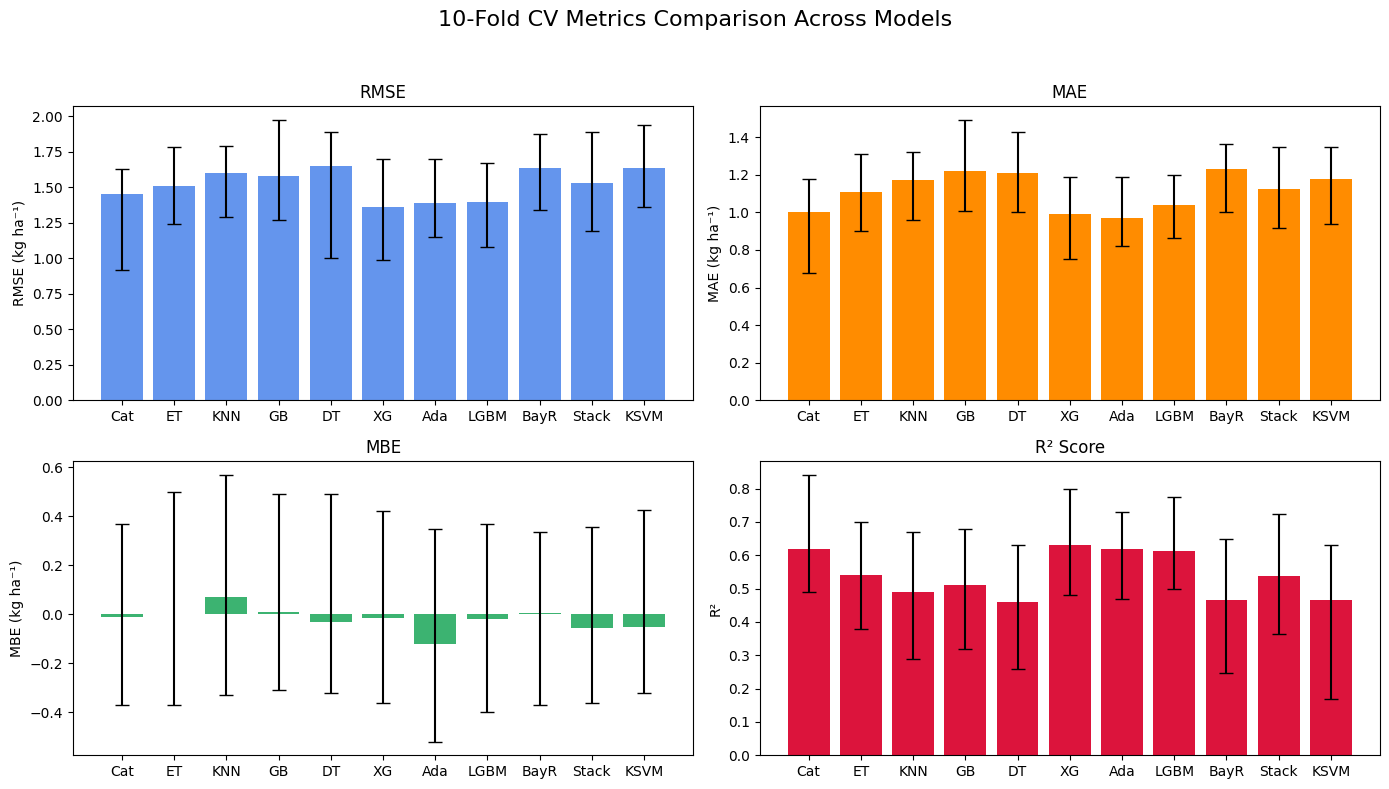


📌 Stacking Metrics Summary (10-Fold CV):
MBE:  Mean = -0.0550, Min = -0.3604, Max = 0.3580
MAE:  Mean = 1.1263, Min = 0.9143, Max = 1.3458
RMSE: Mean = 1.5268, Min = 1.1941, Max = 1.8899
R²:   Mean = 0.5374, Min = 0.3626, Max = 0.7227

📌 KSVM Metrics Summary (10-Fold CV):
MBE:  Mean = -0.0520, Min = -0.3210, Max = 0.4280
MAE:  Mean = 1.1780, Min = 0.9380, Max = 1.3500
RMSE: Mean = 1.6360, Min = 1.3620, Max = 1.9400
R²:   Mean = 0.4650, Min = 0.1700, Max = 0.6300


In [47]:
import matplotlib.pyplot as plt
import numpy as np

# Model names
models = ['Cat', 'ET', 'KNN', 'GB', 'DT', 'XG', 'Ada', 'LGBM', 'BayR', 'Stack', 'KSVM']

# Mean values
rmse = [1.45, 1.51, 1.60, 1.58, 1.65, 1.36, 1.39, 1.3958, 1.6363, 1.5268, 1.636]
mae  = [1.00, 1.11, 1.17, 1.22, 1.21, 0.99, 0.97, 1.0374, 1.2314, 1.1263, 1.178]
mbe  = [-0.01, 0.00, 0.07, 0.01, -0.03, -0.014, -0.121, -0.0187, 0.0047, -0.0550, -0.052]
r2   = [0.62, 0.54, 0.49, 0.51, 0.46, 0.63, 0.618, 0.6134, 0.4673, 0.5374, 0.465]

# Min and Max values for error bars
rmse_min = [0.92, 1.24, 1.29, 1.27, 1.00, 0.99, 1.15, 1.0792, 1.3412, 1.1941, 1.362]
rmse_max = [1.63, 1.78, 1.79, 1.97, 1.89, 1.70, 1.70, 1.6724, 1.8763, 1.8899, 1.94]

mae_min = [0.68, 0.90, 0.96, 1.01, 1.00, 0.75, 0.82, 0.8649, 1.0019, 0.9143, 0.938]
mae_max = [1.18, 1.31, 1.32, 1.49, 1.43, 1.19, 1.19, 1.1996, 1.3659, 1.3458, 1.35]

mbe_min = [-0.37, -0.37, -0.33, -0.31, -0.32, -0.36, -0.52, -0.3972, -0.3711, -0.3604, -0.321]
mbe_max = [0.37, 0.50, 0.57, 0.49, 0.49, 0.42, 0.35, 0.3679, 0.3360, 0.3580, 0.428]

r2_min = [0.49, 0.38, 0.29, 0.32, 0.26, 0.48, 0.47, 0.4983, 0.2455, 0.3626, 0.17]
r2_max = [0.84, 0.70, 0.67, 0.68, 0.63, 0.80, 0.73, 0.7735, 0.6502, 0.7227, 0.63]

# Calculate error bars
rmse_err = [np.abs(np.array(rmse) - np.array(rmse_min)), np.abs(np.array(rmse_max) - np.array(rmse))]
mae_err = [np.abs(np.array(mae) - np.array(mae_min)), np.abs(np.array(mae_max) - np.array(mae))]
mbe_err = [np.abs(np.array(mbe) - np.array(mbe_min)), np.abs(np.array(mbe_max) - np.array(mbe))]
r2_err = [np.abs(np.array(r2) - np.array(r2_min)), np.abs(np.array(r2_max) - np.array(r2))]

# Set homogeneous colors for each metric across all models
colors_rmse = ['cornflowerblue'] * len(models)
colors_mae = ['darkorange'] * len(models)
colors_mbe = ['mediumseagreen'] * len(models)
colors_r2 = ['crimson'] * len(models)

# Plotting
fig, axs = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('10-Fold CV Metrics Comparison Across Models', fontsize=16)

axs[0, 0].bar(models, rmse, color=colors_rmse, yerr=rmse_err, capsize=5)
axs[0, 0].set_title("RMSE")
axs[0, 0].set_ylabel("RMSE (kg ha⁻¹)")

axs[0, 1].bar(models, mae, color=colors_mae, yerr=mae_err, capsize=5)
axs[0, 1].set_title("MAE")
axs[0, 1].set_ylabel("MAE (kg ha⁻¹)")

axs[1, 0].bar(models, mbe, color=colors_mbe, yerr=mbe_err, capsize=5)
axs[1, 0].set_title("MBE")
axs[1, 0].set_ylabel("MBE (kg ha⁻¹)")

axs[1, 1].bar(models, r2, color=colors_r2, yerr=r2_err, capsize=5)
axs[1, 1].set_title("R² Score")
axs[1, 1].set_ylabel("R²")

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# 📌 Print Stacking and KSVM Metrics Summary
print("\n📌 Stacking Metrics Summary (10-Fold CV):")
print(f"MBE:  Mean = {mbe[9]:.4f}, Min = {mbe_min[9]:.4f}, Max = {mbe_max[9]:.4f}")
print(f"MAE:  Mean = {mae[9]:.4f}, Min = {mae_min[9]:.4f}, Max = {mae_max[9]:.4f}")
print(f"RMSE: Mean = {rmse[9]:.4f}, Min = {rmse_min[9]:.4f}, Max = {rmse_max[9]:.4f}")
print(f"R²:   Mean = {r2[9]:.4f}, Min = {r2_min[9]:.4f}, Max = {r2_max[9]:.4f}")

print("\n📌 KSVM Metrics Summary (10-Fold CV):")
print(f"MBE:  Mean = {mbe[10]:.4f}, Min = {mbe_min[10]:.4f}, Max = {mbe_max[10]:.4f}")
print(f"MAE:  Mean = {mae[10]:.4f}, Min = {mae_min[10]:.4f}, Max = {mae_max[10]:.4f}")
print(f"RMSE: Mean = {rmse[10]:.4f}, Min = {rmse_min[10]:.4f}, Max = {rmse_max[10]:.4f}")
print(f"R²:   Mean = {r2[10]:.4f}, Min = {r2_min[10]:.4f}, Max = {r2_max[10]:.4f}")


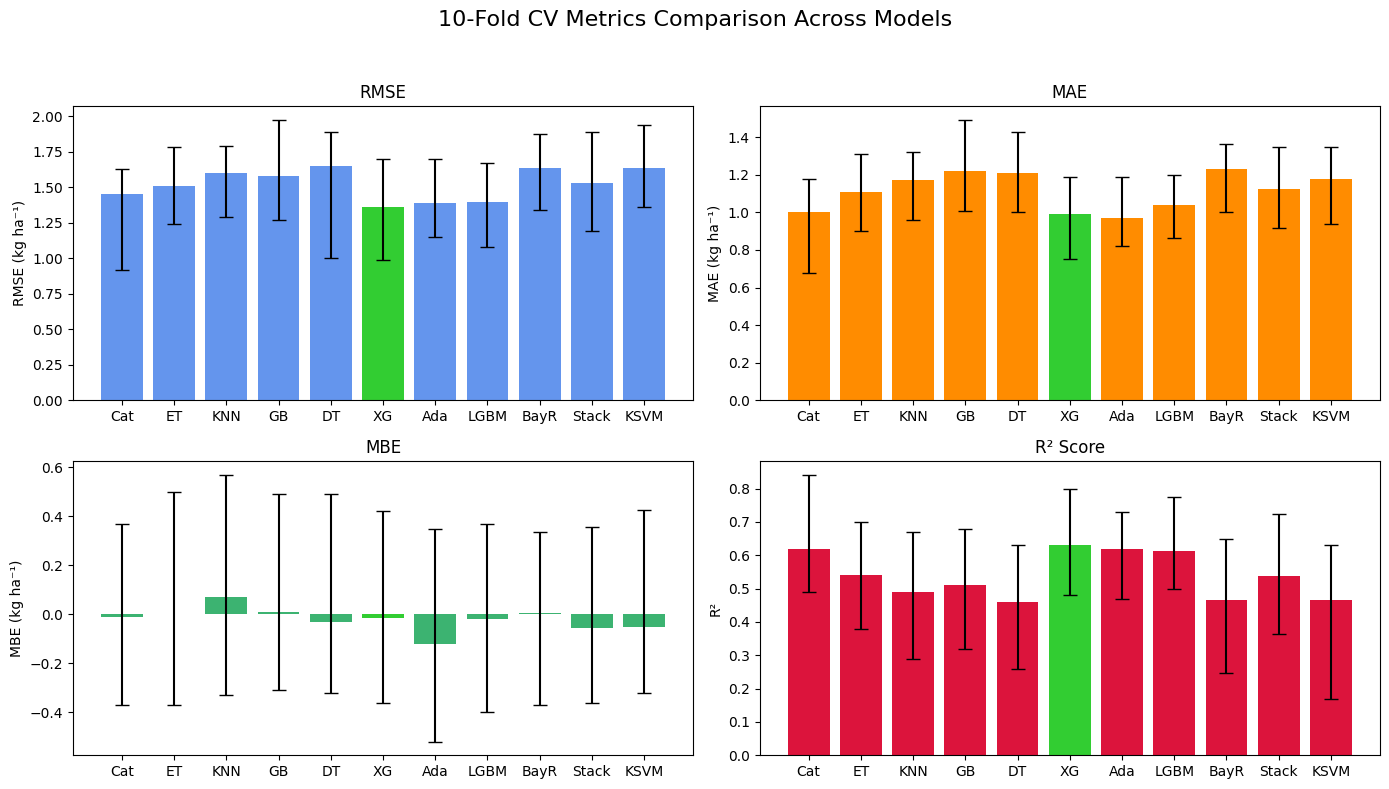


📌 Best Model Metrics Summary (10-Fold CV):
Best Model: XG
MBE:  Mean = -0.0140, Min = -0.3600, Max = 0.4200
MAE:  Mean = 0.9900, Min = 0.7500, Max = 1.1900
RMSE: Mean = 1.3600, Min = 0.9900, Max = 1.7000
R²:   Mean = 0.6300, Min = 0.4800, Max = 0.8000


In [48]:
import matplotlib.pyplot as plt
import numpy as np

# Model names
models = ['Cat', 'ET', 'KNN', 'GB', 'DT', 'XG', 'Ada', 'LGBM', 'BayR', 'Stack', 'KSVM']

# Mean values
rmse = [1.45, 1.51, 1.60, 1.58, 1.65, 1.36, 1.39, 1.3958, 1.6363, 1.5268, 1.636]
mae  = [1.00, 1.11, 1.17, 1.22, 1.21, 0.99, 0.97, 1.0374, 1.2314, 1.1263, 1.178]
mbe  = [-0.01, 0.00, 0.07, 0.01, -0.03, -0.014, -0.121, -0.0187, 0.0047, -0.0550, -0.052]
r2   = [0.62, 0.54, 0.49, 0.51, 0.46, 0.63, 0.618, 0.6134, 0.4673, 0.5374, 0.465]

# Min and Max values for error bars
rmse_min = [0.92, 1.24, 1.29, 1.27, 1.00, 0.99, 1.15, 1.0792, 1.3412, 1.1941, 1.362]
rmse_max = [1.63, 1.78, 1.79, 1.97, 1.89, 1.70, 1.70, 1.6724, 1.8763, 1.8899, 1.94]

mae_min = [0.68, 0.90, 0.96, 1.01, 1.00, 0.75, 0.82, 0.8649, 1.0019, 0.9143, 0.938]
mae_max = [1.18, 1.31, 1.32, 1.49, 1.43, 1.19, 1.19, 1.1996, 1.3659, 1.3458, 1.35]

mbe_min = [-0.37, -0.37, -0.33, -0.31, -0.32, -0.36, -0.52, -0.3972, -0.3711, -0.3604, -0.321]
mbe_max = [0.37, 0.50, 0.57, 0.49, 0.49, 0.42, 0.35, 0.3679, 0.3360, 0.3580, 0.428]

r2_min = [0.49, 0.38, 0.29, 0.32, 0.26, 0.48, 0.47, 0.4983, 0.2455, 0.3626, 0.17]
r2_max = [0.84, 0.70, 0.67, 0.68, 0.63, 0.80, 0.73, 0.7735, 0.6502, 0.7227, 0.63]

# Calculate error bars
rmse_err = [np.abs(np.array(rmse) - np.array(rmse_min)), np.abs(np.array(rmse_max) - np.array(rmse))]
mae_err = [np.abs(np.array(mae) - np.array(mae_min)), np.abs(np.array(mae_max) - np.array(mae))]
mbe_err = [np.abs(np.array(mbe) - np.array(mbe_min)), np.abs(np.array(mbe_max) - np.array(mbe))]
r2_err = [np.abs(np.array(r2) - np.array(r2_min)), np.abs(np.array(r2_max) - np.array(r2))]

# Define best model based on highest R² score
best_model_idx = np.argmax(r2)  # Get index of the best model based on R² score

# Set homogeneous colors for each metric across all models
colors_rmse = ['cornflowerblue'] * len(models)
colors_mae = ['darkorange'] * len(models)
colors_mbe = ['mediumseagreen'] * len(models)
colors_r2 = ['crimson'] * len(models)

# Highlight the best model
colors_rmse[best_model_idx] = 'limegreen'
colors_mae[best_model_idx] = 'limegreen'
colors_mbe[best_model_idx] = 'limegreen'
colors_r2[best_model_idx] = 'limegreen'

# Plotting
fig, axs = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle('10-Fold CV Metrics Comparison Across Models', fontsize=16)

# RMSE
axs[0, 0].bar(models, rmse, color=colors_rmse, yerr=rmse_err, capsize=5)
axs[0, 0].set_title("RMSE")
axs[0, 0].set_ylabel("RMSE (kg ha⁻¹)")

# MAE
axs[0, 1].bar(models, mae, color=colors_mae, yerr=mae_err, capsize=5)
axs[0, 1].set_title("MAE")
axs[0, 1].set_ylabel("MAE (kg ha⁻¹)")

# MBE
axs[1, 0].bar(models, mbe, color=colors_mbe, yerr=mbe_err, capsize=5)
axs[1, 0].set_title("MBE")
axs[1, 0].set_ylabel("MBE (kg ha⁻¹)")

# R²
axs[1, 1].bar(models, r2, color=colors_r2, yerr=r2_err, capsize=5)
axs[1, 1].set_title("R² Score")
axs[1, 1].set_ylabel("R²")

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# 📌 Print Best Model Metrics Summary
print("\n📌 Best Model Metrics Summary (10-Fold CV):")
print(f"Best Model: {models[best_model_idx]}")
print(f"MBE:  Mean = {mbe[best_model_idx]:.4f}, Min = {mbe_min[best_model_idx]:.4f}, Max = {mbe_max[best_model_idx]:.4f}")
print(f"MAE:  Mean = {mae[best_model_idx]:.4f}, Min = {mae_min[best_model_idx]:.4f}, Max = {mae_max[best_model_idx]:.4f}")
print(f"RMSE: Mean = {rmse[best_model_idx]:.4f}, Min = {rmse_min[best_model_idx]:.4f}, Max = {rmse_max[best_model_idx]:.4f}")
print(f"R²:   Mean = {r2[best_model_idx]:.4f}, Min = {r2_min[best_model_idx]:.4f}, Max = {r2_max[best_model_idx]:.4f}")


KNN

In [ ]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# === Step 1: Load and Clean Data ===
df = pd.read_csv("cleaned_file_OM_withoutfield_1.csv")
df = df[df['OM'] <= 12].dropna(subset=['OM'])

X = df.drop(columns=['OM', 'SAMPLEDATE', 'lati', 'long', 'Planet_BI_1'], errors='ignore')
y = df['OM']
X = X.dropna()
y = y.loc[X.index]

# === Step 2: Initial Scaling ===
scaler_full = StandardScaler()
X_scaled = scaler_full.fit_transform(X)

# === Step 3: Permutation Importance with Base KNN ===
knn_base = KNeighborsRegressor(n_neighbors=10, weights='distance')
knn_base.fit(X_scaled, y)
perm_importance = permutation_importance(knn_base, X_scaled, y, scoring='r2', n_repeats=10, random_state=42)

# === Step 4: Select Top 40% Most Important Features ===
importances = perm_importance.importances_mean
feature_names = X.columns
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

top_k = int(0.4 * len(feature_names))
selected_features = importance_df['Feature'].iloc[:top_k].tolist()
print(f"📌 Selected Features ({top_k} of {len(feature_names)}):")
for f in selected_features:
    print(f" - {f}")

X_selected = X[selected_features]

# === Step 5: Scale Selected Features ===
scaler = StandardScaler()
X_selected_scaled = scaler.fit_transform(X_selected)

# === Step 6: Hyperparameter Tuning with GridSearch ===
param_grid = {
    'n_neighbors': [3, 5, 7, 10, 15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}
grid_search = GridSearchCV(KNeighborsRegressor(), param_grid, cv=10, scoring='r2', n_jobs=-1)
grid_search.fit(X_selected_scaled, y)
best_knn = grid_search.best_estimator_
print("\n✅ Best Hyperparameters:")
print(grid_search.best_params_)

# === Step 7: 10-Fold Cross-Validation Metrics ===
kf = KFold(n_splits=10, shuffle=True, random_state=42)
metrics = {'mbe': [], 'mae': [], 'rmse': [], 'r2': []}

print("\n📊 Per Fold Metrics:")
for i, (train_idx, val_idx) in enumerate(kf.split(X_selected_scaled), 1):
    X_t, X_v = X_selected_scaled[train_idx], X_selected_scaled[val_idx]
    y_t, y_v = y.iloc[train_idx], y.iloc[val_idx]
    best_knn.fit(X_t, y_t)
    y_pred = best_knn.predict(X_v)

    mbe = np.mean(y_pred - y_v)
    mae = mean_absolute_error(y_v, y_pred)
    rmse = np.sqrt(mean_squared_error(y_v, y_pred))
    r2 = r2_score(y_v, y_pred)

    metrics['mbe'].append(mbe)
    metrics['mae'].append(mae)
    metrics['rmse'].append(rmse)
    metrics['r2'].append(r2)

    print(f"Fold {i} → MBE: {mbe:.4f}, MAE: {mae:.4f}, RMSE: {rmse:.4f}, R²: {r2:.4f}")

# === Step 8: Final Metrics ===
print("\n📌 Average 10-Fold Metrics:")
print(f"MBE:  {np.mean(metrics['mbe']):.4f}")
print(f"MAE:  {np.mean(metrics['mae']):.4f}")
print(f"RMSE: {np.mean(metrics['rmse']):.4f}")
print(f"R²:   {np.mean(metrics['r2']):.4f}")

# === Step 9: Save Model & Artifacts ===
joblib.dump(best_knn, "best_knn_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(selected_features, "selected_features.pkl")


📌 Selected Features (12 of 32):
 - Senti_BI_1
 - MRVBF
 - Relative_Elev
 - Convergence_Index
 - Aspect
 - Convexity
 - Mid_Slope_Position
 - gNASGO_SC
 - PH_Polaris
 - Profile_curva
 - Tang_curva
 - Alpha_Polaris

✅ Best Hyperparameters:
{'metric': 'manhattan', 'n_neighbors': 10, 'weights': 'distance'}

📊 Per Fold Metrics:
Fold 1 → MBE: 0.3213, MAE: 1.3183, RMSE: 1.7921, R²: 0.2907
Fold 2 → MBE: -0.2065, MAE: 1.2501, RMSE: 1.6797, R²: 0.5020
Fold 3 → MBE: -0.1026, MAE: 1.0326, RMSE: 1.5213, R²: 0.5379
Fold 4 → MBE: -0.2586, MAE: 1.3094, RMSE: 1.7690, R²: 0.5307
Fold 5 → MBE: 0.4007, MAE: 1.1398, RMSE: 1.5722, R²: 0.4462
Fold 6 → MBE: 0.1380, MAE: 1.0316, RMSE: 1.2917, R²: 0.6677
Fold 7 → MBE: 0.0090, MAE: 0.9626, RMSE: 1.3767, R²: 0.6314
Fold 8 → MBE: 0.5665, MAE: 1.1337, RMSE: 1.5923, R²: 0.4041
Fold 9 → MBE: -0.3323, MAE: 1.2667, RMSE: 1.7732, R²: 0.5262
Fold 10 → MBE: 0.1167, MAE: 1.2552, RMSE: 1.6869, R²: 0.3323

📌 Average 10-Fold Metrics:
MBE:  0.0652
MAE:  1.1700
RMSE: 1.6055
R²:

['selected_features.pkl']

GB

In [ ]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# === Step 1: Load and Clean Data ===
df = pd.read_csv("cleaned_file_OM_withoutfield_1.csv")
df = df[df['OM'] <= 12].dropna(subset=['OM'])

X = df.drop(columns=['OM', 'SAMPLEDATE', 'lati', 'long', 'Planet_BI_1'], errors='ignore')
y = df['OM']
X = X.dropna()
y = y.loc[X.index]

# === Step 2: Initial Scaling ===
scaler_full = StandardScaler()
X_scaled = scaler_full.fit_transform(X)

# === Step 3: Permutation Importance with Base GB ===
gb_base = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
gb_base.fit(X_scaled, y)
perm_importance = permutation_importance(gb_base, X_scaled, y, scoring='r2', n_repeats=10, random_state=42)

# === Step 4: Select Top 40% Most Important Features ===
importances = perm_importance.importances_mean
feature_names = X.columns
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

top_k = int(0.4 * len(feature_names))
selected_features = importance_df['Feature'].iloc[:top_k].tolist()
print(f"📌 Selected Features ({top_k} of {len(feature_names)}):")
for f in selected_features:
    print(f" - {f}")

X_selected = X[selected_features]

# === Step 5: Scale Selected Features ===
scaler = StandardScaler()
X_selected_scaled = scaler.fit_transform(X_selected)

# === Step 6: Hyperparameter Tuning with GridSearch ===
param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 10],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'subsample': [0.8, 1.0]
}
grid_search = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1
)
grid_search.fit(X_selected_scaled, y)
best_gb = grid_search.best_estimator_
print("\n✅ Best Hyperparameters:")
print(grid_search.best_params_)

# === Step 7: 10-Fold Cross-Validation Metrics ===
kf = KFold(n_splits=10, shuffle=True, random_state=42)
metrics = {'mbe': [], 'mae': [], 'rmse': [], 'r2': []}

print("\n📊 Per Fold Metrics:")
for i, (train_idx, val_idx) in enumerate(kf.split(X_selected_scaled), 1):
    X_t, X_v = X_selected_scaled[train_idx], X_selected_scaled[val_idx]
    y_t, y_v = y.iloc[train_idx], y.iloc[val_idx]
    best_gb.fit(X_t, y_t)
    y_pred = best_gb.predict(X_v)

    mbe = np.mean(y_pred - y_v)
    mae = mean_absolute_error(y_v, y_pred)
    rmse = np.sqrt(mean_squared_error(y_v, y_pred))
    r2 = r2_score(y_v, y_pred)

    metrics['mbe'].append(mbe)
    metrics['mae'].append(mae)
    metrics['rmse'].append(rmse)
    metrics['r2'].append(r2)

    print(f"Fold {i} → MBE: {mbe:.4f}, MAE: {mae:.4f}, RMSE: {rmse:.4f}, R²: {r2:.4f}")

# === Step 8: Final Metrics ===
print("\n📌 Average 10-Fold Metrics:")
print(f"MBE:  {np.mean(metrics['mbe']):.4f}")
print(f"MAE:  {np.mean(metrics['mae']):.4f}")
print(f"RMSE: {np.mean(metrics['rmse']):.4f}")
print(f"R²:   {np.mean(metrics['r2']):.4f}")

# === Step 9: Save Model & Artifacts ===
joblib.dump(best_gb, "best_gb_model.pkl")
joblib.dump(scaler, "scaler_gb.pkl")
joblib.dump(selected_features, "selected_features_gb.pkl")


📌 Selected Features (12 of 32):
 - gNASGO_SC
 - Senti_BI_1
 - MRVBF
 - Lamda_Polaris
 - Ksat_Polaris
 - Clay_polaris
 - pctearthmc
 - Polaris_SC
 - Relative_Elev
 - TWI
 - PH_Polaris
 - ncci3all

✅ Best Hyperparameters:
{'learning_rate': 0.01, 'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100, 'subsample': 1.0}

📊 Per Fold Metrics:
Fold 1 → MBE: 0.1714, MAE: 1.2050, RMSE: 1.6277, R²: 0.4148
Fold 2 → MBE: -0.1656, MAE: 1.1513, RMSE: 1.5070, R²: 0.5992
Fold 3 → MBE: -0.1795, MAE: 1.2234, RMSE: 1.5280, R²: 0.5338
Fold 4 → MBE: -0.3065, MAE: 1.4855, RMSE: 1.9700, R²: 0.4180
Fold 5 → MBE: 0.4912, MAE: 1.1209, RMSE: 1.3776, R²: 0.5748
Fold 6 → MBE: -0.0676, MAE: 1.1256, RMSE: 1.4378, R²: 0.5883
Fold 7 → MBE: 0.0527, MAE: 1.0065, RMSE: 1.2747, R²: 0.6840
Fold 8 → MBE: 0.4360, MAE: 1.1249, RMSE: 1.5105, R²: 0.4638
Fold 9 → MBE: -0.2681, MAE: 1.4092, RMSE: 1.8648, R²: 0.4760
Fold 10 → MBE: -0.0809, MAE: 1.3105, RMSE: 1.6992, R²: 0.3225

📌 Average 10-Fold Metric

['selected_features_gb.pkl']

DT

In [ ]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# === Step 1: Load and Clean Data ===
df = pd.read_csv("cleaned_file_OM_withoutfield_1.csv")
df = df[df['OM'] <= 12].dropna(subset=['OM'])

X = df.drop(columns=['OM', 'SAMPLEDATE', 'lati', 'long', 'Planet_BI_1'], errors='ignore')
y = df['OM']
X = X.dropna()
y = y.loc[X.index]

# === Step 2: Initial Scaling ===
scaler_full = StandardScaler()
X_scaled = scaler_full.fit_transform(X)

# === Step 3: Permutation Importance with Base DT ===
dt_base = DecisionTreeRegressor(random_state=42)
dt_base.fit(X_scaled, y)
perm_importance = permutation_importance(dt_base, X_scaled, y, scoring='r2', n_repeats=10, random_state=42)

# === Step 4: Select Top 40% Most Important Features ===
importances = perm_importance.importances_mean
feature_names = X.columns
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

top_k = int(0.4 * len(feature_names))
selected_features = importance_df['Feature'].iloc[:top_k].tolist()
print(f"📌 Selected Features ({top_k} of {len(feature_names)}):")
for f in selected_features:
    print(f" - {f}")

X_selected = X[selected_features]

# === Step 5: Scale Selected Features ===
scaler = StandardScaler()
X_selected_scaled = scaler.fit_transform(X_selected)

# === Step 6: Hyperparameter Tuning with GridSearch ===
param_grid = {
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
grid_search = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1
)
grid_search.fit(X_selected_scaled, y)
best_dt = grid_search.best_estimator_
print("\n✅ Best Hyperparameters:")
print(grid_search.best_params_)

# === Step 7: 10-Fold Cross-Validation Metrics ===
kf = KFold(n_splits=10, shuffle=True, random_state=42)
metrics = {'mbe': [], 'mae': [], 'rmse': [], 'r2': []}

print("\n📊 Per Fold Metrics:")
for i, (train_idx, val_idx) in enumerate(kf.split(X_selected_scaled), 1):
    X_t, X_v = X_selected_scaled[train_idx], X_selected_scaled[val_idx]
    y_t, y_v = y.iloc[train_idx], y.iloc[val_idx]
    best_dt.fit(X_t, y_t)
    y_pred = best_dt.predict(X_v)

    mbe = np.mean(y_pred - y_v)
    mae = mean_absolute_error(y_v, y_pred)
    rmse = np.sqrt(mean_squared_error(y_v, y_pred))
    r2 = r2_score(y_v, y_pred)

    metrics['mbe'].append(mbe)
    metrics['mae'].append(mae)
    metrics['rmse'].append(rmse)
    metrics['r2'].append(r2)

    print(f"Fold {i} → MBE: {mbe:.4f}, MAE: {mae:.4f}, RMSE: {rmse:.4f}, R²: {r2:.4f}")

# === Step 8: Final Metrics ===
print("\n📌 Average 10-Fold Metrics:")
print(f"MBE:  {np.mean(metrics['mbe']):.4f}")
print(f"MAE:  {np.mean(metrics['mae']):.4f}")
print(f"RMSE: {np.mean(metrics['rmse']):.4f}")
print(f"R²:   {np.mean(metrics['r2']):.4f}")

# === Step 9: Save Model & Artifacts ===
joblib.dump(best_dt, "best_dt_model.pkl")
joblib.dump(scaler, "scaler_dt.pkl")
joblib.dump(selected_features, "selected_features_dt.pkl")


📌 Selected Features (12 of 32):
 - Clay_polaris
 - gNASGO_SC
 - Senti_BI_1
 - MRVBF
 - pctearthmc
 - Relative_Elev
 - aws_5_20s
 - TWI
 - Alpha_Polaris
 - Valley_Depth
 - Theta_r_Polaris
 - PH_Polaris

✅ Best Hyperparameters:
{'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 5}

📊 Per Fold Metrics:
Fold 1 → MBE: 0.3050, MAE: 1.2778, RMSE: 1.7677, R²: 0.3098
Fold 2 → MBE: -0.1822, MAE: 1.2286, RMSE: 1.6911, R²: 0.4953
Fold 3 → MBE: -0.3163, MAE: 1.1419, RMSE: 1.5393, R²: 0.5268
Fold 4 → MBE: -0.3139, MAE: 1.4269, RMSE: 1.8864, R²: 0.4663
Fold 5 → MBE: 0.4949, MAE: 1.1960, RMSE: 1.5829, R²: 0.4386
Fold 6 → MBE: -0.2400, MAE: 1.1036, RMSE: 1.5143, R²: 0.5433
Fold 7 → MBE: -0.0544, MAE: 1.0011, RMSE: 1.3779, R²: 0.6308
Fold 8 → MBE: 0.4103, MAE: 1.1502, RMSE: 1.5694, R²: 0.4211
Fold 9 → MBE: -0.3186, MAE: 1.2176, RMSE: 1.7911, R²: 0.5166
Fold 10 → MBE: -0.0722, MAE: 1.3239, RMSE: 1.7757, R²: 0.2601

📌 Average 10-Fold Metrics:
MBE:  -0.0287
MAE:  1.2068
RMSE: 1.6496
R²:   0.4609


['selected_features_dt.pkl']

XGBOOST

In [ ]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# === Step 1: Load and Clean Data ===
df = pd.read_csv("cleaned_file_OM_withoutfield_1.csv")
df = df[df['OM'] <= 12].dropna(subset=['OM'])

X = df.drop(columns=['OM', 'SAMPLEDATE', 'lati', 'long', 'Planet_BI_1'], errors='ignore')
y = df['OM']
X = X.dropna()
y = y.loc[X.index]

# === Step 2: Initial Scaling ===
scaler_full = StandardScaler()
X_scaled = scaler_full.fit_transform(X)

# === Step 3: Permutation Importance with Base XGBoost ===
xgb_base = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42, verbosity=0)
xgb_base.fit(X_scaled, y)
perm_importance = permutation_importance(xgb_base, X_scaled, y, scoring='r2', n_repeats=10, random_state=42)

# === Step 4: Select Top 40% Most Important Features ===
importances = perm_importance.importances_mean
feature_names = X.columns
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

top_k = int(0.4 * len(feature_names))
selected_features = importance_df['Feature'].iloc[:top_k].tolist()
print(f"📌 Selected Features ({top_k} of {len(feature_names)}):")
for f in selected_features:
    print(f" - {f}")

X_selected = X[selected_features]

# === Step 5: Scale Selected Features ===
scaler = StandardScaler()
X_selected_scaled = scaler.fit_transform(X_selected)

# === Step 6: Hyperparameter Tuning with GridSearch ===
param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 10],
    'min_child_weight': [1, 3, 5],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}
grid_search = GridSearchCV(
    XGBRegressor(random_state=42, verbosity=0),
    param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1
)
grid_search.fit(X_selected_scaled, y)
best_xgb = grid_search.best_estimator_
print("\n✅ Best Hyperparameters:")
print(grid_search.best_params_)

# === Step 7: 10-Fold Cross-Validation Metrics ===
kf = KFold(n_splits=10, shuffle=True, random_state=42)
metrics = {'mbe': [], 'mae': [], 'rmse': [], 'r2': []}

print("\n📊 Per Fold Metrics:")
for i, (train_idx, val_idx) in enumerate(kf.split(X_selected_scaled), 1):
    X_t, X_v = X_selected_scaled[train_idx], X_selected_scaled[val_idx]
    y_t, y_v = y.iloc[train_idx], y.iloc[val_idx]
    best_xgb.fit(X_t, y_t)
    y_pred = best_xgb.predict(X_v)

    mbe = np.mean(y_pred - y_v)
    mae = mean_absolute_error(y_v, y_pred)
    rmse = np.sqrt(mean_squared_error(y_v, y_pred))
    r2 = r2_score(y_v, y_pred)

    metrics['mbe'].append(mbe)
    metrics['mae'].append(mae)
    metrics['rmse'].append(rmse)
    metrics['r2'].append(r2)

    print(f"Fold {i} → MBE: {mbe:.4f}, MAE: {mae:.4f}, RMSE: {rmse:.4f}, R²: {r2:.4f}")

# === Step 8: Final Metrics ===
print("\n📌 Average 10-Fold Metrics:")
print(f"MBE:  {np.mean(metrics['mbe']):.4f}")
print(f"MAE:  {np.mean(metrics['mae']):.4f}")
print(f"RMSE: {np.mean(metrics['rmse']):.4f}")
print(f"R²:   {np.mean(metrics['r2']):.4f}")

# === Step 9: Save Model & Artifacts ===
joblib.dump(best_xgb, "best_xgb_model.pkl")
joblib.dump(scaler, "scaler_xgb.pkl")
joblib.dump(selected_features, "selected_features_xgb.pkl")


📌 Selected Features (12 of 32):
 - gNASGO_SC
 - Senti_BI_1
 - Clay_polaris
 - Lamda_Polaris
 - MRVBF
 - Polaris_SC
 - Ksat_Polaris
 - Relative_Elev
 - pctearthmc
 - TWI
 - HB_Polaris
 - ncci3all

✅ Best Hyperparameters:
{'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 5, 'min_child_weight': 3, 'n_estimators': 100, 'subsample': 0.8}

📊 Per Fold Metrics:
Fold 1 → MBE: 0.1840, MAE: 1.0835, RMSE: 1.4270, R²: 0.5502
Fold 2 → MBE: -0.1248, MAE: 0.9624, RMSE: 1.2432, R²: 0.7272
Fold 3 → MBE: -0.3653, MAE: 0.8088, RMSE: 1.2308, R²: 0.6975
Fold 4 → MBE: -0.2857, MAE: 1.0936, RMSE: 1.5625, R²: 0.6339
Fold 5 → MBE: 0.4278, MAE: 1.0399, RMSE: 1.3045, R²: 0.6187
Fold 6 → MBE: 0.0017, MAE: 0.9042, RMSE: 1.1650, R²: 0.7297
Fold 7 → MBE: 0.0150, MAE: 0.7561, RMSE: 0.9995, R²: 0.8057
Fold 8 → MBE: 0.3990, MAE: 1.0421, RMSE: 1.4831, R²: 0.4830
Fold 9 → MBE: -0.3515, MAE: 1.1913, RMSE: 1.7037, R²: 0.5626
Fold 10 → MBE: -0.0437, MAE: 1.0970, RMSE: 1.4572, R²: 0.5018

📌 Average 10-Fold Metrics

['selected_features_xgb.pkl']

TEST_XGBOOST

🔍 Features used for prediction:
 - gNASGO_SC
 - Senti_BI_1
 - Clay_polaris
 - Lamda_Polaris
 - MRVBF
 - Polaris_SC
 - Ksat_Polaris
 - Relative_Elev
 - pctearthmc
 - TWI
 - HB_Polaris
 - ncci3all

📊 Test Set Metrics (XGBoost):
MAE:  0.8055
RMSE: 1.1750
R²:   0.6404


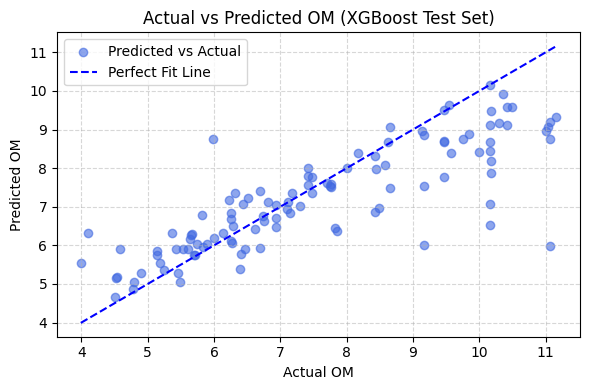

In [ ]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# === Step 1: Load test data ===
df_test = pd.read_csv("Antho_Test_1_field.csv")
df_test = df_test.dropna(subset=['OM'])

# === Step 2: Load model artifacts for XGBoost ===
model = joblib.load("best_xgb_model.pkl")       # ✅ XGBoost model
scaler = joblib.load("scaler_xgb.pkl")          # ✅ Scaler for selected features
selected_features = joblib.load("selected_features_xgb.pkl")

# === Step 3: Display selected features used for prediction ===
print("🔍 Features used for prediction:")
for feature in selected_features:
    print(f" - {feature}")

# === Step 4: Prepare test features ===
X_test_raw = df_test.drop(columns=['OM', 'SAMPLEDATE', 'lati', 'long', 'Planet_BI_1'], errors='ignore')
y_test = df_test['OM']

# Add missing columns and maintain order
for col in selected_features:
    if col not in X_test_raw.columns:
        X_test_raw[col] = 0

X_test_final = X_test_raw[selected_features]
X_test_final = X_test_final.fillna(0)

# === Step 5: Scale test features ===
X_test_scaled = scaler.transform(X_test_final)

# === Step 6: Predict and evaluate ===
y_pred = model.predict(X_test_scaled)

print("\n📊 Test Set Metrics (XGBoost):")
print(f"MAE:  {mean_absolute_error(y_test, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")
print(f"R²:   {r2_score(y_test, y_pred):.4f}")

# === Step 7: Plot Actual vs Predicted ===
plt.figure(figsize=(6, 4))
plt.scatter(y_test, y_pred, alpha=0.6, color="royalblue", label="Predicted vs Actual")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'b--', label="Perfect Fit Line")
plt.title("Actual vs Predicted OM (XGBoost Test Set)")
plt.xlabel("Actual OM")
plt.ylabel("Predicted OM")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


ADA_BOOST_TRAIN

In [ ]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# === Step 1: Load and Clean Data ===
df = pd.read_csv("cleaned_file_OM_withoutfield_1.csv")
df = df[df['OM'] <= 12].dropna(subset=['OM'])

X = df.drop(columns=['OM', 'SAMPLEDATE', 'lati', 'long', 'Planet_BI_1'], errors='ignore')
y = df['OM']
X = X.dropna()
y = y.loc[X.index]

# === Step 2: Initial Scaling ===
scaler_full = StandardScaler()
X_scaled = scaler_full.fit_transform(X)

# === Step 3: Permutation Importance with Base AdaBoost ===
base_est = DecisionTreeRegressor(max_depth=3)
ada_base = AdaBoostRegressor(estimator=base_est, n_estimators=100, learning_rate=0.1, random_state=42)
ada_base.fit(X_scaled, y)
perm_importance = permutation_importance(ada_base, X_scaled, y, scoring='r2', n_repeats=10, random_state=42)

# === Step 4: Select Top 40% Most Important Features ===
importances = perm_importance.importances_mean
feature_names = X.columns
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

top_k = int(0.4 * len(feature_names))
selected_features = importance_df['Feature'].iloc[:top_k].tolist()
print(f"📌 Selected Features ({top_k} of {len(feature_names)}):")
for f in selected_features:
    print(f" - {f}")

X_selected = X[selected_features]

# === Step 5: Scale Selected Features ===
scaler = StandardScaler()
X_selected_scaled = scaler.fit_transform(X_selected)

# === Step 6: Hyperparameter Tuning with GridSearch ===
param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'estimator__max_depth': [3, 5, 10]
}
grid_search = GridSearchCV(
    AdaBoostRegressor(estimator=DecisionTreeRegressor(), random_state=42),
    param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1
)
grid_search.fit(X_selected_scaled, y)
best_ada = grid_search.best_estimator_
print("\n✅ Best Hyperparameters:")
print(grid_search.best_params_)

# === Step 7: 10-Fold Cross-Validation Metrics ===
kf = KFold(n_splits=10, shuffle=True, random_state=42)
metrics = {'mbe': [], 'mae': [], 'rmse': [], 'r2': []}

print("\n📊 Per Fold Metrics:")
for i, (train_idx, val_idx) in enumerate(kf.split(X_selected_scaled), 1):
    X_t, X_v = X_selected_scaled[train_idx], X_selected_scaled[val_idx]
    y_t, y_v = y.iloc[train_idx], y.iloc[val_idx]
    best_ada.fit(X_t, y_t)
    y_pred = best_ada.predict(X_v)

    mbe = np.mean(y_pred - y_v)
    mae = mean_absolute_error(y_v, y_pred)
    rmse = np.sqrt(mean_squared_error(y_v, y_pred))
    r2 = r2_score(y_v, y_pred)

    metrics['mbe'].append(mbe)
    metrics['mae'].append(mae)
    metrics['rmse'].append(rmse)
    metrics['r2'].append(r2)

    print(f"Fold {i} → MBE: {mbe:.4f}, MAE: {mae:.4f}, RMSE: {rmse:.4f}, R²: {r2:.4f}")

# === Step 8: Final Metrics ===
print("\n📌 Average 10-Fold Metrics:")
print(f"MBE:  {np.mean(metrics['mbe']):.4f}")
print(f"MAE:  {np.mean(metrics['mae']):.4f}")
print(f"RMSE: {np.mean(metrics['rmse']):.4f}")
print(f"R²:   {np.mean(metrics['r2']):.4f}")

# === Step 9: Save Model & Artifacts ===
joblib.dump(best_ada, "best_ada_model.pkl")
joblib.dump(scaler, "scaler_ada.pkl")
joblib.dump(selected_features, "selected_features_ada.pkl")


📌 Selected Features (12 of 32):
 - gNASGO_SC
 - Senti_BI_1
 - PH_Polaris
 - MRVBF
 - n_Polaris
 - pctearthmc
 - Theta_r_Polaris
 - Ksat_Polaris
 - SILT_Polaris
 - Clay_polaris
 - Polaris_SC
 - ncci3all

✅ Best Hyperparameters:
{'estimator__max_depth': 10, 'learning_rate': 0.2, 'n_estimators': 100}

📊 Per Fold Metrics:
Fold 1 → MBE: 0.0481, MAE: 1.0738, RMSE: 1.4957, R²: 0.5059
Fold 2 → MBE: -0.1150, MAE: 0.9592, RMSE: 1.3308, R²: 0.6874
Fold 3 → MBE: -0.3733, MAE: 0.8288, RMSE: 1.1780, R²: 0.7229
Fold 4 → MBE: -0.5217, MAE: 1.1902, RMSE: 1.6884, R²: 0.5725
Fold 5 → MBE: 0.3540, MAE: 0.9541, RMSE: 1.2659, R²: 0.6409
Fold 6 → MBE: -0.1586, MAE: 0.8284, RMSE: 1.1538, R²: 0.7349
Fold 7 → MBE: -0.1397, MAE: 0.8213, RMSE: 1.1742, R²: 0.7319
Fold 8 → MBE: 0.2677, MAE: 0.9211, RMSE: 1.3881, R²: 0.5472
Fold 9 → MBE: -0.4218, MAE: 1.0802, RMSE: 1.6978, R²: 0.5656
Fold 10 → MBE: -0.1516, MAE: 1.0689, RMSE: 1.4958, R²: 0.4750

📌 Average 10-Fold Metrics:
MBE:  -0.1212
MAE:  0.9726
RMSE: 1.3869
R²: 

['selected_features_ada.pkl']

ADA_TEST

🔍 Features used for prediction:
 - gNASGO_SC
 - Senti_BI_1
 - PH_Polaris
 - MRVBF
 - n_Polaris
 - pctearthmc
 - Theta_r_Polaris
 - Ksat_Polaris
 - SILT_Polaris
 - Clay_polaris
 - Polaris_SC
 - ncci3all

📊 Test Set Metrics (AdaBoost):
MBE:  -0.1009
MAE:  0.3127
RMSE: 0.8830
R²:   0.7969


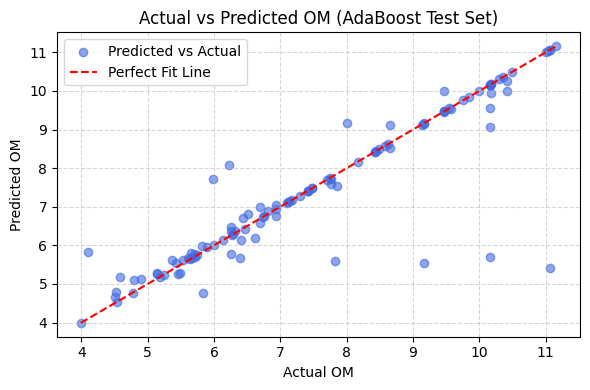

In [ ]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# === Step 1: Load test data ===
df_test = pd.read_csv("Antho_Test_1_field.csv")
df_test = df_test.dropna(subset=['OM'])

# === Step 2: Load model artifacts for AdaBoost ===
model = joblib.load("best_ada_model.pkl")        # ✅ AdaBoost model
scaler = joblib.load("scaler_ada.pkl")           # ✅ Scaler for selected features
selected_features = joblib.load("selected_features_ada.pkl")

# === Step 3: Display selected features used for prediction ===
print("🔍 Features used for prediction:")
for feature in selected_features:
    print(f" - {feature}")

# === Step 4: Prepare test features ===
X_test_raw = df_test.drop(columns=['OM', 'SAMPLEDATE', 'lati', 'long', 'Planet_BI_1'], errors='ignore')
y_test = df_test['OM']

# Add missing columns and maintain order
for col in selected_features:
    if col not in X_test_raw.columns:
        X_test_raw[col] = 0

X_test_final = X_test_raw[selected_features]
X_test_final = X_test_final.fillna(0)

# === Step 5: Scale test features ===
X_test_scaled = scaler.transform(X_test_final)

# === Step 6: Predict and evaluate ===
y_pred = model.predict(X_test_scaled)

# Calculate metrics
mbe = np.mean(y_pred - y_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

# Print metrics
print("\n📊 Test Set Metrics (AdaBoost):")
print(f"MBE:  {mbe:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²:   {r2:.4f}")

# === Step 7: Plot Actual vs Predicted ===
plt.figure(figsize=(6, 4))
plt.scatter(y_test, y_pred, alpha=0.6, color="royalblue", label="Predicted vs Actual")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label="Perfect Fit Line")
plt.title("Actual vs Predicted OM (AdaBoost Test Set)")
plt.xlabel("Actual OM")
plt.ylabel("Predicted OM")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


CAT_regression_train

In [ ]:
pip install catboost



📊 Per Fold Metrics:
Fold 1: MBE=0.1336, MAE=1.0931, RMSE=1.5180, R²=0.4911
Fold 2: MBE=-0.1267, MAE=0.9720, RMSE=1.2994, R²=0.7020
Fold 3: MBE=-0.2409, MAE=0.9009, RMSE=1.2749, R²=0.6754
Fold 4: MBE=-0.3604, MAE=1.1823, RMSE=1.6293, R²=0.6019
Fold 5: MBE=0.3667, MAE=1.0157, RMSE=1.2971, R²=0.6231
Fold 6: MBE=-0.0083, MAE=0.9100, RMSE=1.2182, R²=0.7044
Fold 7: MBE=-0.0002, MAE=0.6827, RMSE=0.9169, R²=0.8365
Fold 8: MBE=0.3661, MAE=0.9674, RMSE=1.3612, R²=0.5645
Fold 9: MBE=-0.3272, MAE=1.0334, RMSE=1.5477, R²=0.6390
Fold 10: MBE=0.0090, MAE=1.0711, RMSE=1.4516, R²=0.5056

📌 Average 10-Fold Metrics:
MBE:  -0.0188
MAE:  0.9829
RMSE: 1.3514
R²:   0.6344


/tmp/ipython-input-28-822122711.py:96: UserWarning: Glyph 128204 (\N{PUSHPIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128204 (\N{PUSHPIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


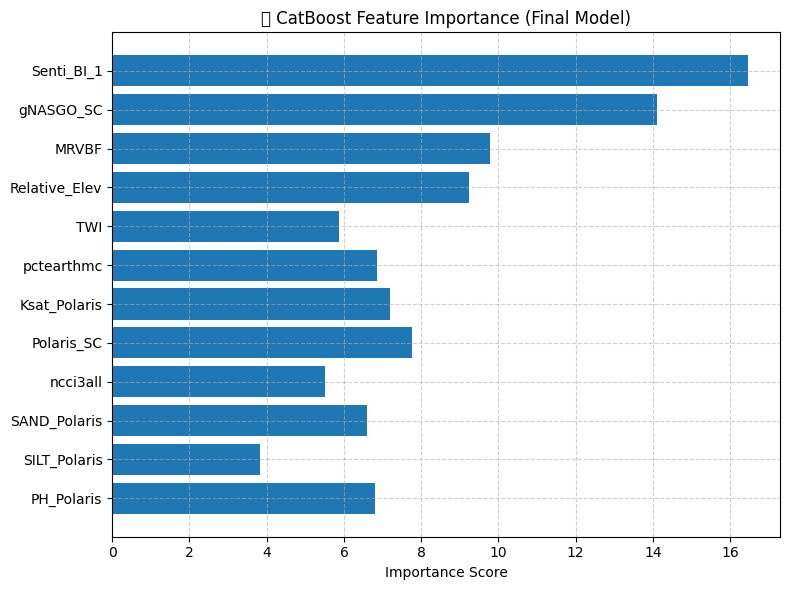

In [28]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from catboost import CatBoostRegressor, Pool
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# === Step 1: Load and Clean Data ===
df = pd.read_csv("cleaned_file_OM_withoutfield_1.csv")
df = df[df['OM'] <= 12].dropna(subset=['OM'])

X = df.drop(columns=['OM', 'SAMPLEDATE', 'lati', 'long', 'Planet_BI_1'], errors='ignore')
y = df['OM']
X = X.dropna()
y = y.loc[X.index]

# === Step 2: Initial Scaling ===
scaler_full = StandardScaler()
X_scaled = scaler_full.fit_transform(X)

# === Step 3: Permutation Importance ===
cat_base = CatBoostRegressor(verbose=0, random_state=42)
cat_base.fit(X_scaled, y)
perm_importance = permutation_importance(cat_base, X_scaled, y, scoring='r2', n_repeats=10, random_state=42)

importances = perm_importance.importances_mean
importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances}).sort_values(by='Importance', ascending=False)

top_k = int(0.4 * len(X.columns))
selected_features = importance_df['Feature'].iloc[:top_k].tolist()
X_selected = X[selected_features]

# === Step 4: Scaling Selected Features ===
scaler = StandardScaler()
X_selected_scaled = scaler.fit_transform(X_selected)

# === Step 5: Hyperparameter Tuning ===
param_grid = {
    'iterations': [100, 200],
    'learning_rate': [0.01, 0.1],
    'depth': [4, 6, 8],
    'l2_leaf_reg': [1, 3, 5]
}
grid_search = GridSearchCV(CatBoostRegressor(verbose=0, random_state=42), param_grid, cv=3, scoring='r2', n_jobs=-1)
grid_search.fit(X_selected_scaled, y)
best_cat = grid_search.best_estimator_

# === Step 6: 10-Fold Cross-Validation ===
kf = KFold(n_splits=10, shuffle=True, random_state=42)
metrics = {'mbe': [], 'mae': [], 'rmse': [], 'r2': []}

print("\n📊 Per Fold Metrics:")
for fold, (train_idx, val_idx) in enumerate(kf.split(X_selected_scaled), 1):
    X_t, X_v = X_selected_scaled[train_idx], X_selected_scaled[val_idx]
    y_t, y_v = y.iloc[train_idx], y.iloc[val_idx]

    best_cat.fit(X_t, y_t)
    y_pred = best_cat.predict(X_v)

    mbe = np.mean(y_pred - y_v)
    mae = mean_absolute_error(y_v, y_pred)
    rmse = np.sqrt(mean_squared_error(y_v, y_pred))
    r2 = r2_score(y_v, y_pred)

    metrics['mbe'].append(mbe)
    metrics['mae'].append(mae)
    metrics['rmse'].append(rmse)
    metrics['r2'].append(r2)

    print(f"Fold {fold}: MBE={mbe:.4f}, MAE={mae:.4f}, RMSE={rmse:.4f}, R²={r2:.4f}")

# === Step 7: Average Metrics ===
print("\n📌 Average 10-Fold Metrics:")
print(f"MBE:  {np.mean(metrics['mbe']):.4f}")
print(f"MAE:  {np.mean(metrics['mae']):.4f}")
print(f"RMSE: {np.mean(metrics['rmse']):.4f}")
print(f"R²:   {np.mean(metrics['r2']):.4f}")

# === Step 8: Save Artifacts ===
joblib.dump(best_cat, "best_cat_model.pkl")
joblib.dump(scaler, "scaler_cat.pkl")
joblib.dump(selected_features, "selected_features_cat.pkl")

# === Step 9: Feature Importance Plot from Final Model ===
final_feat_importance = best_cat.get_feature_importance(Pool(X_selected_scaled, label=y))

plt.figure(figsize=(8, 6))
plt.barh(selected_features, final_feat_importance)
plt.title("📌 CatBoost Feature Importance (Final Model)")
plt.xlabel("Importance Score")
plt.gca().invert_yaxis()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


CAT_TEST

🔍 Features used for prediction:
 - Senti_BI_1
 - gNASGO_SC
 - MRVBF
 - Relative_Elev
 - TWI
 - pctearthmc
 - Ksat_Polaris
 - Polaris_SC
 - ncci3all
 - SAND_Polaris
 - SILT_Polaris
 - PH_Polaris

📊 Test Set Metrics (CatBoost):
MBE:  -0.1900
MAE:  0.4784
RMSE: 0.8952
R²:   0.7912


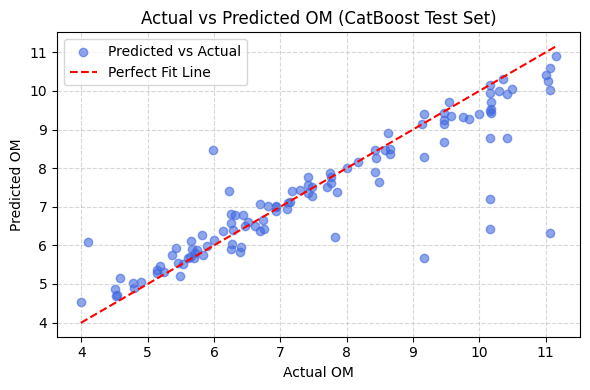

In [29]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from catboost import CatBoostRegressor

# === Step 1: Load test data ===
df_test = pd.read_csv("Antho_Test_1_field.csv")
df_test = df_test.dropna(subset=['OM'])

# === Step 2: Load model artifacts for CatBoost ===
model = joblib.load("best_cat_model.pkl")        # ✅ CatBoost model
scaler = joblib.load("scaler_cat.pkl")           # ✅ Scaler for selected features
selected_features = joblib.load("selected_features_cat.pkl")

# === Step 3: Display selected features used for prediction ===
print("🔍 Features used for prediction:")
for feature in selected_features:
    print(f" - {feature}")

# === Step 4: Prepare test features ===
X_test_raw = df_test.drop(columns=['OM', 'SAMPLEDATE', 'lati', 'long', 'Planet_BI_1'], errors='ignore')
y_test = df_test['OM']

# Add missing columns and maintain order
for col in selected_features:
    if col not in X_test_raw.columns:
        X_test_raw[col] = 0

X_test_final = X_test_raw[selected_features]
X_test_final = X_test_final.fillna(0)

# === Step 5: Scale test features ===
X_test_scaled = scaler.transform(X_test_final)

# === Step 6: Predict and evaluate ===
y_pred = model.predict(X_test_scaled)

# === Step 7: Calculate metrics ===
mbe = np.mean(y_pred - y_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\n📊 Test Set Metrics (CatBoost):")
print(f"MBE:  {mbe:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²:   {r2:.4f}")

# === Step 8: Plot Actual vs Predicted ===
plt.figure(figsize=(6, 4))
plt.scatter(y_test, y_pred, alpha=0.6, color="royalblue", label="Predicted vs Actual")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label="Perfect Fit Line")
plt.title("Actual vs Predicted OM (CatBoost Test Set)")
plt.xlabel("Actual OM")
plt.ylabel("Predicted OM")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


Train_LightGBM

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11


📊 Per Fold Metrics:
Fold 1: MBE=0.0958, MAE=1.0064, RMSE=1.4231, R²=0.5527
Fold 2: MBE=0.0566, MAE=1.0411, RMSE=1.3650, R²=0.6711


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11

Fold 3: MBE=-0.2851, MAE=0.9318, RMSE=1.3227, R²=0.6507
Fold 4: MBE=-0.3972, MAE=1.1362, RMSE=1.5828, R²=0.6243
Fold 5: MBE=0.3679, MAE=1.1415, RMSE=1.4104, R²=0.5543


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Fold 6: MBE=-0.0503, MAE=0.9703, RMSE=1.2265, R²=0.7004
Fold 7: MBE=-0.0059, MAE=0.8649, RMSE=1.0792, R²=0.7735
Fold 8: MBE=0.2997, MAE=1.0117, RMSE=1.4611, R²=0.4983


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Fold 9: MBE=-0.2345, MAE=1.1996, RMSE=1.6724, R²=0.5786
Fold 10: MBE=-0.0341, MAE=1.0706, RMSE=1.4148, R²=0.5303

📌 Average 10-Fold Metrics:
MBE:  -0.0187
MAE:  1.0374
RMSE: 1.3958
R²:   0.6134


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128204 (\N{PUSHPIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


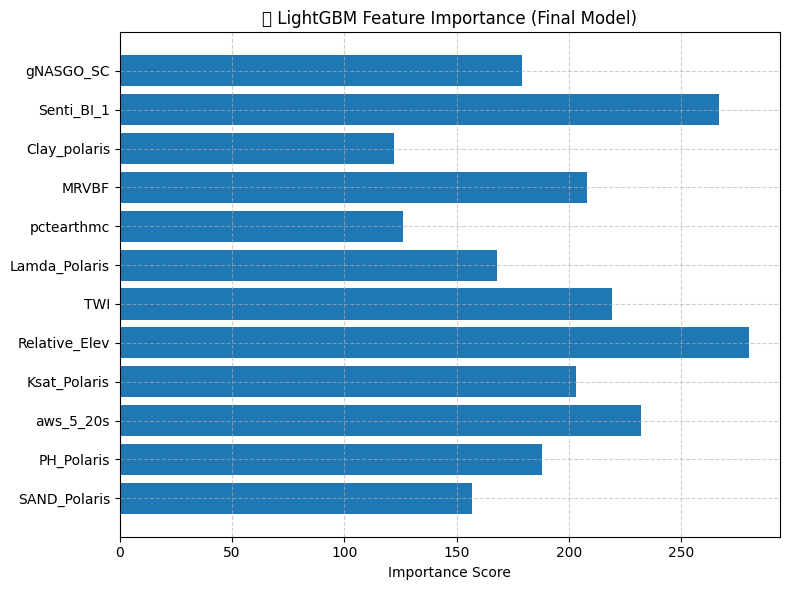

In [ ]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from lightgbm import LGBMRegressor
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# === Step 1: Load and Clean Data ===
df = pd.read_csv("cleaned_file_OM_withoutfield_1.csv")
df = df[df['OM'] <= 12].dropna(subset=['OM'])

X = df.drop(columns=['OM', 'SAMPLEDATE', 'lati', 'long', 'Planet_BI_1'], errors='ignore')
y = df['OM']
X = X.dropna()
y = y.loc[X.index]

# === Step 2: Initial Scaling ===
scaler_full = StandardScaler()
X_scaled = scaler_full.fit_transform(X)

# === Step 3: Permutation Importance ===
lgb_base = LGBMRegressor(random_state=42, verbose=-1)
lgb_base.fit(X_scaled, y)
perm_importance = permutation_importance(lgb_base, X_scaled, y, scoring='r2', n_repeats=10, random_state=42)

importances = perm_importance.importances_mean
importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances}).sort_values(by='Importance', ascending=False)

top_k = int(0.4 * len(X.columns))
selected_features = importance_df['Feature'].iloc[:top_k].tolist()
X_selected = X[selected_features]

# === Step 4: Scale Selected Features ===
scaler = StandardScaler()
X_selected_scaled = scaler.fit_transform(X_selected)

# === Step 5: Hyperparameter Tuning ===
param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1],
    'max_depth': [4, 6, 8],
    'num_leaves': [15, 31, 63],
    'reg_alpha': [0, 0.1, 1.0]
}

grid_search = GridSearchCV(LGBMRegressor(random_state=42, verbose=-1), param_grid, cv=3, scoring='r2', n_jobs=-1)
grid_search.fit(X_selected_scaled, y)
best_lgb = grid_search.best_estimator_

# === Step 6: 10-Fold Cross-Validation ===
kf = KFold(n_splits=10, shuffle=True, random_state=42)
metrics = {'mbe': [], 'mae': [], 'rmse': [], 'r2': []}

print("\n📊 Per Fold Metrics:")
for fold, (train_idx, val_idx) in enumerate(kf.split(X_selected_scaled), 1):
    X_t, X_v = X_selected_scaled[train_idx], X_selected_scaled[val_idx]
    y_t, y_v = y.iloc[train_idx], y.iloc[val_idx]

    best_lgb.fit(X_t, y_t)
    y_pred = best_lgb.predict(X_v)

    mbe = np.mean(y_pred - y_v)
    mae = mean_absolute_error(y_v, y_pred)
    rmse = np.sqrt(mean_squared_error(y_v, y_pred))
    r2 = r2_score(y_v, y_pred)

    metrics['mbe'].append(mbe)
    metrics['mae'].append(mae)
    metrics['rmse'].append(rmse)
    metrics['r2'].append(r2)

    print(f"Fold {fold}: MBE={mbe:.4f}, MAE={mae:.4f}, RMSE={rmse:.4f}, R²={r2:.4f}")

# === Step 7: Average Metrics ===
print("\n📌 Average 10-Fold Metrics:")
print(f"MBE:  {np.mean(metrics['mbe']):.4f}")
print(f"MAE:  {np.mean(metrics['mae']):.4f}")
print(f"RMSE: {np.mean(metrics['rmse']):.4f}")
print(f"R²:   {np.mean(metrics['r2']):.4f}")

# === Step 8: Save Artifacts ===
joblib.dump(best_lgb, "best_lgb_model.pkl")
joblib.dump(scaler, "scaler_lgb.pkl")
joblib.dump(selected_features, "selected_features_lgb.pkl")

# === Step 9: Plot Feature Importances ===
feat_importance = best_lgb.feature_importances_

plt.figure(figsize=(8, 6))
plt.barh(selected_features, feat_importance)
plt.title("📌 LightGBM Feature Importance (Final Model)")
plt.xlabel("Importance Score")
plt.gca().invert_yaxis()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


In [ ]:
# === Step 8: Save Artifacts ===
joblib.dump(best_lgb, "best_lgb_model.pkl")
joblib.dump(scaler, "scaler_lgb.pkl")
joblib.dump(selected_features, "selected_features_lgb.pkl")

['selected_features_lgb.pkl']

TEST_LIGHTGBM

🔍 Features used for prediction:
 - gNASGO_SC
 - Senti_BI_1
 - Clay_polaris
 - MRVBF
 - pctearthmc
 - Lamda_Polaris
 - TWI
 - Relative_Elev
 - Ksat_Polaris
 - aws_5_20s
 - PH_Polaris
 - SAND_Polaris

📊 Test Set Metrics (LightGBM):
MBE:  -0.2117
MAE:  0.5436
RMSE: 0.9101
R²:   0.7843


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


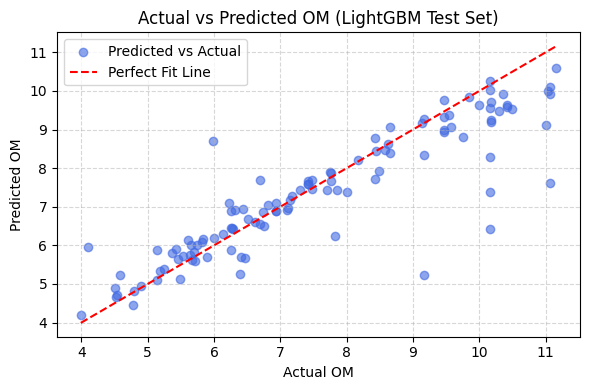

In [ ]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from lightgbm import LGBMRegressor

# === Step 1: Load test data ===
df_test = pd.read_csv("Antho_Test_1_field.csv")
df_test = df_test.dropna(subset=['OM'])

# === Step 2: Load model artifacts for LightGBM ===
model = joblib.load("best_lgb_model.pkl")        # ✅ LightGBM model
scaler = joblib.load("scaler_lgb.pkl")           # ✅ Scaler for selected features
selected_features = joblib.load("selected_features_lgb.pkl")

# === Step 3: Display selected features used for prediction ===
print("🔍 Features used for prediction:")
for feature in selected_features:
    print(f" - {feature}")

# === Step 4: Prepare test features ===
X_test_raw = df_test.drop(columns=['OM', 'SAMPLEDATE', 'lati', 'long', 'Planet_BI_1'], errors='ignore')
y_test = df_test['OM']

# Add missing columns and maintain order
for col in selected_features:
    if col not in X_test_raw.columns:
        X_test_raw[col] = 0

X_test_final = X_test_raw[selected_features]
X_test_final = X_test_final.fillna(0)

# === Step 5: Scale test features ===
X_test_scaled = scaler.transform(X_test_final)

# === Step 6: Predict and evaluate ===
y_pred = model.predict(X_test_scaled)

# === Step 7: Calculate metrics ===
mbe = np.mean(y_pred - y_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\n📊 Test Set Metrics (LightGBM):")
print(f"MBE:  {mbe:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²:   {r2:.4f}")

# === Step 8: Plot Actual vs Predicted ===
plt.figure(figsize=(6, 4))
plt.scatter(y_test, y_pred, alpha=0.6, color="royalblue", label="Predicted vs Actual")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label="Perfect Fit Line")
plt.title("Actual vs Predicted OM (LightGBM Test Set)")
plt.xlabel("Actual OM")
plt.ylabel("Predicted OM")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


Train_Bayasian_Ridge


📊 Per Fold Metrics:
Fold 1: MBE=0.3200, MAE=1.3054, RMSE=1.7199, R²=0.3466
Fold 2: MBE=-0.0848, MAE=1.3294, RMSE=1.6760, R²=0.5042
Fold 3: MBE=-0.2531, MAE=1.0875, RMSE=1.4373, R²=0.5875
Fold 4: MBE=-0.3711, MAE=1.3659, RMSE=1.8402, R²=0.4922
Fold 5: MBE=0.3063, MAE=1.1629, RMSE=1.4670, R²=0.5178
Fold 6: MBE=0.0176, MAE=1.1469, RMSE=1.4830, R²=0.5620
Fold 7: MBE=0.0205, MAE=1.0019, RMSE=1.3412, R²=0.6502
Fold 8: MBE=0.3360, MAE=1.2576, RMSE=1.7918, R²=0.2455
Fold 9: MBE=-0.3396, MAE=1.3644, RMSE=1.8763, R²=0.4695
Fold 10: MBE=0.0955, MAE=1.2921, RMSE=1.7301, R²=0.2977

📌 Average 10-Fold Metrics:
MBE:  0.0047
MAE:  1.2314
RMSE: 1.6363
R²:   0.4673


/tmp/ipython-input-6-1431996782.py:89: UserWarning: Glyph 128204 (\N{PUSHPIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


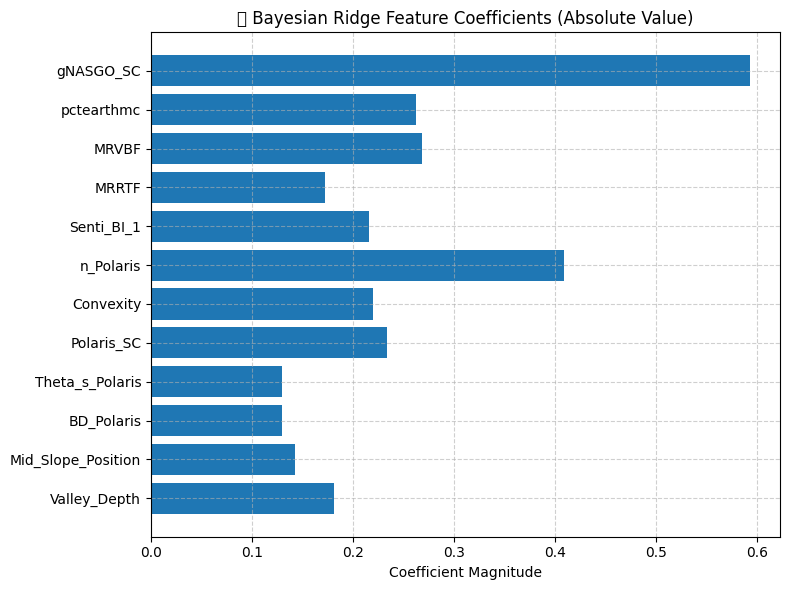

In [ ]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.linear_model import BayesianRidge
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# === Step 1: Load and Clean Data ===
df = pd.read_csv("cleaned_file_OM_withoutfield_1.csv")
df = df[df['OM'] <= 12].dropna(subset=['OM'])

X = df.drop(columns=['OM', 'SAMPLEDATE', 'lati', 'long', 'Planet_BI_1'], errors='ignore')
y = df['OM']
X = X.dropna()
y = y.loc[X.index]

# === Step 2: Initial Scaling ===
scaler_full = StandardScaler()
X_scaled = scaler_full.fit_transform(X)

# === Step 3: Permutation Importance ===
ridge_base = BayesianRidge()
ridge_base.fit(X_scaled, y)
perm_importance = permutation_importance(ridge_base, X_scaled, y, scoring='r2', n_repeats=10, random_state=42)

importances = perm_importance.importances_mean
importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances}).sort_values(by='Importance', ascending=False)

top_k = int(0.4 * len(X.columns))
selected_features = importance_df['Feature'].iloc[:top_k].tolist()
X_selected = X[selected_features]

# === Step 4: Scale Selected Features ===
scaler = StandardScaler()
X_selected_scaled = scaler.fit_transform(X_selected)

# === Step 5: Use Best Bayesian Ridge Model (no hyperparameters to tune here) ===
best_ridge = BayesianRidge()
best_ridge.fit(X_selected_scaled, y)

# === Step 6: 10-Fold Cross-Validation ===
kf = KFold(n_splits=10, shuffle=True, random_state=42)
metrics = {'mbe': [], 'mae': [], 'rmse': [], 'r2': []}

print("\n📊 Per Fold Metrics:")
for fold, (train_idx, val_idx) in enumerate(kf.split(X_selected_scaled), 1):
    X_t, X_v = X_selected_scaled[train_idx], X_selected_scaled[val_idx]
    y_t, y_v = y.iloc[train_idx], y.iloc[val_idx]

    best_ridge.fit(X_t, y_t)
    y_pred = best_ridge.predict(X_v)

    mbe = np.mean(y_pred - y_v)
    mae = mean_absolute_error(y_v, y_pred)
    rmse = np.sqrt(mean_squared_error(y_v, y_pred))
    r2 = r2_score(y_v, y_pred)

    metrics['mbe'].append(mbe)
    metrics['mae'].append(mae)
    metrics['rmse'].append(rmse)
    metrics['r2'].append(r2)

    print(f"Fold {fold}: MBE={mbe:.4f}, MAE={mae:.4f}, RMSE={rmse:.4f}, R²={r2:.4f}")

# === Step 7: Average Metrics ===
print("\n📌 Average 10-Fold Metrics:")
print(f"MBE:  {np.mean(metrics['mbe']):.4f}")
print(f"MAE:  {np.mean(metrics['mae']):.4f}")
print(f"RMSE: {np.mean(metrics['rmse']):.4f}")
print(f"R²:   {np.mean(metrics['r2']):.4f}")

# === Step 8: Save Artifacts ===
joblib.dump(best_ridge, "best_bayes_model.pkl")
joblib.dump(scaler, "scaler_bayes.pkl")
joblib.dump(selected_features, "selected_features_bayes.pkl")

# === Step 9: Plot Coefficients ===
coef_importance = best_ridge.coef_

plt.figure(figsize=(8, 6))
plt.barh(selected_features, np.abs(coef_importance))
plt.title("📌 Bayesian Ridge Feature Coefficients (Absolute Value)")
plt.xlabel("Coefficient Magnitude")
plt.gca().invert_yaxis()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


MLP_Train


📊 Per Fold Metrics:


/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


Fold 1: MBE=0.1580, MAE=1.4081, RMSE=1.9537, R²=0.1570


/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


Fold 2: MBE=0.1633, MAE=1.3886, RMSE=1.8589, R²=0.3901


...

/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


Fold 9: MBE=-0.4232, MAE=1.3254, RMSE=1.8262, R²=0.4974


/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


Fold 10: MBE=-0.0166, MAE=1.3865, RMSE=1.8312, R²=0.2132

📌 Average 10-Fold Metrics:
MBE:  -0.0454
MAE:  1.2852
RMSE: 1.7626
R²:   0.3809


/tmp/ipython-input-8-2447934667.py:91: UserWarning: Glyph 128204 (\N{PUSHPIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128204 (\N{PUSHPIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


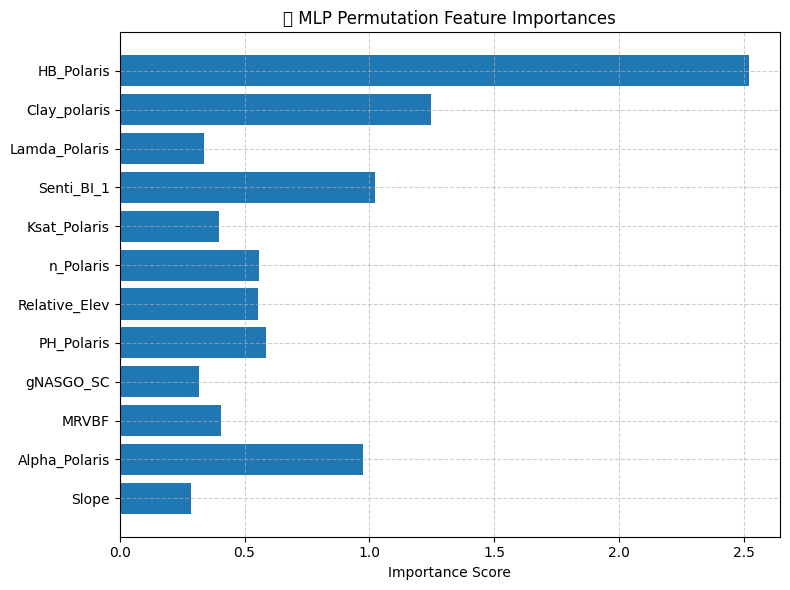

In [ ]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# === Step 1: Load and Clean Data ===
df = pd.read_csv("cleaned_file_OM_withoutfield_1.csv")
df = df[df['OM'] <= 12].dropna(subset=['OM'])

X = df.drop(columns=['OM', 'SAMPLEDATE', 'lati', 'long', 'Planet_BI_1'], errors='ignore')
y = df['OM']
X = X.dropna()
y = y.loc[X.index]

# === Step 2: Initial Scaling ===
scaler_full = StandardScaler()
X_scaled = scaler_full.fit_transform(X)

# === Step 3: Permutation Importance using base MLP ===
mlp_base = MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=1000, random_state=42)
mlp_base.fit(X_scaled, y)
perm_importance = permutation_importance(mlp_base, X_scaled, y, scoring='r2', n_repeats=10, random_state=42)

importances = perm_importance.importances_mean
importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances}).sort_values(by='Importance', ascending=False)

top_k = int(0.4 * len(X.columns))
selected_features = importance_df['Feature'].iloc[:top_k].tolist()
X_selected = X[selected_features]

# === Step 4: Final Scaling of Selected Features ===
scaler = StandardScaler()
X_selected_scaled = scaler.fit_transform(X_selected)

# === Step 5: Initialize Final MLP Regressor ===
best_mlp = MLPRegressor(hidden_layer_sizes=(64, 32), activation='relu',
                        solver='adam', learning_rate_init=0.001,
                        max_iter=1000, random_state=42)

# === Step 6: 10-Fold Cross-Validation ===
kf = KFold(n_splits=10, shuffle=True, random_state=42)
metrics = {'mbe': [], 'mae': [], 'rmse': [], 'r2': []}

print("\n📊 Per Fold Metrics:")
for fold, (train_idx, val_idx) in enumerate(kf.split(X_selected_scaled), 1):
    X_t, X_v = X_selected_scaled[train_idx], X_selected_scaled[val_idx]
    y_t, y_v = y.iloc[train_idx], y.iloc[val_idx]

    best_mlp.fit(X_t, y_t)
    y_pred = best_mlp.predict(X_v)

    mbe = np.mean(y_pred - y_v)
    mae = mean_absolute_error(y_v, y_pred)
    rmse = np.sqrt(mean_squared_error(y_v, y_pred))
    r2 = r2_score(y_v, y_pred)

    metrics['mbe'].append(mbe)
    metrics['mae'].append(mae)
    metrics['rmse'].append(rmse)
    metrics['r2'].append(r2)

    print(f"Fold {fold}: MBE={mbe:.4f}, MAE={mae:.4f}, RMSE={rmse:.4f}, R²={r2:.4f}")

# === Step 7: Average Metrics ===
print("\n📌 Average 10-Fold Metrics:")
print(f"MBE:  {np.mean(metrics['mbe']):.4f}")
print(f"MAE:  {np.mean(metrics['mae']):.4f}")
print(f"RMSE: {np.mean(metrics['rmse']):.4f}")
print(f"R²:   {np.mean(metrics['r2']):.4f}")

# === Step 8: Save Artifacts ===
joblib.dump(best_mlp, "best_mlp_model.pkl")
joblib.dump(scaler, "scaler_mlp.pkl")
joblib.dump(selected_features, "selected_features_mlp.pkl")

# === Step 9: Plot Feature Importance (via Permutation) ===
mlp_final_importance = permutation_importance(best_mlp, X_selected_scaled, y, scoring='r2', n_repeats=10, random_state=42)
final_importances = mlp_final_importance.importances_mean

plt.figure(figsize=(8, 6))
plt.barh(selected_features, final_importances)
plt.title("📌 MLP Permutation Feature Importances")
plt.xlabel("Importance Score")
plt.gca().invert_yaxis()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


Stacking

In [23]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor, StackingRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

# === Step 1: Load and Clean Data ===
df = pd.read_csv("cleaned_file_OM_withoutfield_1.csv")
df = df[df['OM'] <= 12].dropna(subset=['OM'])

X = df.drop(columns=['OM', 'SAMPLEDATE', 'lati', 'long', 'Planet_BI_1'], errors='ignore')
y = df['OM']
X = X.dropna()
y = y.loc[X.index]

# === Step 2: Feature Selection Using RF Permutation Importance ===
scaler_full = StandardScaler()
X_scaled = scaler_full.fit_transform(X)

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_scaled, y)
perm = permutation_importance(rf, X_scaled, y, n_repeats=10, scoring='r2', random_state=42)
importances = perm.importances_mean
importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances}).sort_values(by='Importance', ascending=False)

top_k = int(0.4 * len(X.columns))
selected_features = importance_df['Feature'].iloc[:top_k].tolist()
X_selected = X[selected_features]

# === Step 3: Scale Selected Features ===
scaler = StandardScaler()
X_scaled_selected = scaler.fit_transform(X_selected)

# === Step 4: Define Base and Meta Models ===
base_models = [
    ('rf', RandomForestRegressor(n_estimators=100, max_depth=8, random_state=42)),
    ('xgb', XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=6, verbosity=0, random_state=42)),

    ('ada', AdaBoostRegressor(n_estimators=100, learning_rate=0.1, random_state=42))
]

meta_model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.05, max_depth=4, random_state=42)

stack = StackingRegressor(estimators=base_models, final_estimator=meta_model, n_jobs=-1, passthrough=True)

# === Step 5: 10-Fold Cross-Validation ===
kf = KFold(n_splits=10, shuffle=True, random_state=42)
metrics = {'mbe': [], 'mae': [], 'rmse': [], 'r2': []}

print("\n📊 Per Fold Metrics:")
for fold, (train_idx, val_idx) in enumerate(kf.split(X_scaled_selected), 1):
    X_t, X_v = X_scaled_selected[train_idx], X_scaled_selected[val_idx]
    y_t, y_v = y.iloc[train_idx], y.iloc[val_idx]

    stack.fit(X_t, y_t)
    y_pred = stack.predict(X_v)

    mbe = np.mean(y_pred - y_v)
    mae = mean_absolute_error(y_v, y_pred)
    rmse = np.sqrt(mean_squared_error(y_v, y_pred))
    r2 = r2_score(y_v, y_pred)

    metrics['mbe'].append(mbe)
    metrics['mae'].append(mae)
    metrics['rmse'].append(rmse)
    metrics['r2'].append(r2)

    print(f"Fold {fold}: MBE={mbe:.4f}, MAE={mae:.4f}, RMSE={rmse:.4f}, R²={r2:.4f}")

# === Step 6: Summary ===
print("\n📌 Average 10-Fold Metrics:")
print(f"MBE:  {np.mean(metrics['mbe']):.4f}")
print(f"MAE:  {np.mean(metrics['mae']):.4f}")
print(f"RMSE: {np.mean(metrics['rmse']):.4f}")
print(f"R²:   {np.mean(metrics['r2']):.4f}")

# === Step 7: Save Artifacts ===
joblib.dump(stack, "best_stacked_model_gbr.pkl")
joblib.dump(scaler, "scaler_stack_gbr.pkl")
joblib.dump(selected_features, "selected_features_stack_gbr.pkl")



📊 Per Fold Metrics:
Fold 1: MBE=0.1245, MAE=1.1987, RMSE=1.6988, R²=0.3626
Fold 2: MBE=-0.1418, MAE=1.1614, RMSE=1.5202, R²=0.5921
Fold 3: MBE=-0.3514, MAE=1.0702, RMSE=1.5237, R²=0.5364
Fold 4: MBE=-0.3293, MAE=1.2389, RMSE=1.7118, R²=0.5606
Fold 5: MBE=0.3580, MAE=1.0494, RMSE=1.2885, R²=0.6281
Fold 6: MBE=-0.0885, MAE=1.0300, RMSE=1.3328, R²=0.6462
Fold 7: MBE=-0.0244, MAE=0.9143, RMSE=1.1941, R²=0.7227
Fold 8: MBE=0.3434, MAE=1.0649, RMSE=1.4938, R²=0.4756
Fold 9: MBE=-0.3604, MAE=1.3458, RMSE=1.8899, R²=0.4618
Fold 10: MBE=-0.0797, MAE=1.1895, RMSE=1.6148, R²=0.3881

📌 Average 10-Fold Metrics:
MBE:  -0.0550
MAE:  1.1263
RMSE: 1.5268
R²:   0.5374


['selected_features_stack_gbr.pkl']

KSVM


📊 Per Fold Metrics:
Fold 1: MBE=-0.1859, MAE=1.3495, RMSE=1.9384, R²=0.1701
Fold 2: MBE=-0.2266, MAE=1.2683, RMSE=1.6780, R²=0.5030
Fold 3: MBE=-0.3210, MAE=1.0753, RMSE=1.4478, R²=0.5814
Fold 4: MBE=-0.2010, MAE=1.2841, RMSE=1.7904, R²=0.5193
Fold 5: MBE=0.1433, MAE=1.2396, RMSE=1.7491, R²=0.3146
Fold 6: MBE=-0.0677, MAE=0.9382, RMSE=1.3616, R²=0.6308
Fold 7: MBE=0.2456, MAE=1.0835, RMSE=1.3903, R²=0.6241
Fold 8: MBE=0.4289, MAE=1.1668, RMSE=1.6131, R²=0.3885
Fold 9: MBE=-0.2075, MAE=1.2479, RMSE=1.8059, R²=0.5086
Fold 10: MBE=-0.1292, MAE=1.1342, RMSE=1.5869, R²=0.4092

📌 Average 10-Fold Metrics:
MBE:  -0.0521
MAE:  1.1787
RMSE: 1.6361
R²:   0.4650


/tmp/ipython-input-26-3969946447.py:90: UserWarning: Glyph 128204 (\N{PUSHPIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128204 (\N{PUSHPIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


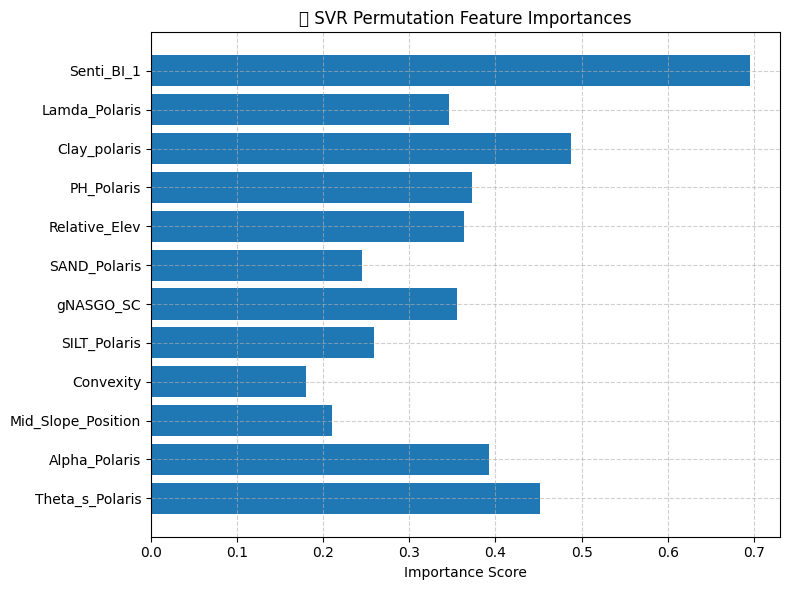

In [26]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from sklearn.svm import SVR
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# === Step 1: Load and Clean Data ===
df = pd.read_csv("cleaned_file_OM_withoutfield_1.csv")
df = df[df['OM'] <= 12].dropna(subset=['OM'])

X = df.drop(columns=['OM', 'SAMPLEDATE', 'lati', 'long', 'Planet_BI_1'], errors='ignore')
y = df['OM']
X = X.dropna()
y = y.loc[X.index]

# === Step 2: Initial Scaling ===
scaler_full = StandardScaler()
X_scaled = scaler_full.fit_transform(X)

# === Step 3: Permutation Importance using base SVR ===
svr_base = SVR(kernel='rbf', C=100, epsilon=0.1)
svr_base.fit(X_scaled, y)
perm_importance = permutation_importance(svr_base, X_scaled, y, scoring='r2', n_repeats=10, random_state=42)

importances = perm_importance.importances_mean
importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances}).sort_values(by='Importance', ascending=False)

top_k = int(0.4 * len(X.columns))
selected_features = importance_df['Feature'].iloc[:top_k].tolist()
X_selected = X[selected_features]

# === Step 4: Final Scaling of Selected Features ===
scaler = StandardScaler()
X_selected_scaled = scaler.fit_transform(X_selected)

# === Step 5: Initialize Final SVR Model ===
best_svr = SVR(kernel='rbf', C=100, epsilon=0.1)

# === Step 6: 10-Fold Cross-Validation ===
kf = KFold(n_splits=10, shuffle=True, random_state=42)
metrics = {'mbe': [], 'mae': [], 'rmse': [], 'r2': []}

print("\n📊 Per Fold Metrics:")
for fold, (train_idx, val_idx) in enumerate(kf.split(X_selected_scaled), 1):
    X_t, X_v = X_selected_scaled[train_idx], X_selected_scaled[val_idx]
    y_t, y_v = y.iloc[train_idx], y.iloc[val_idx]

    best_svr.fit(X_t, y_t)
    y_pred = best_svr.predict(X_v)

    mbe = np.mean(y_pred - y_v)
    mae = mean_absolute_error(y_v, y_pred)
    rmse = np.sqrt(mean_squared_error(y_v, y_pred))
    r2 = r2_score(y_v, y_pred)

    metrics['mbe'].append(mbe)
    metrics['mae'].append(mae)
    metrics['rmse'].append(rmse)
    metrics['r2'].append(r2)

    print(f"Fold {fold}: MBE={mbe:.4f}, MAE={mae:.4f}, RMSE={rmse:.4f}, R²={r2:.4f}")

# === Step 7: Average Metrics ===
print("\n📌 Average 10-Fold Metrics:")
print(f"MBE:  {np.mean(metrics['mbe']):.4f}")
print(f"MAE:  {np.mean(metrics['mae']):.4f}")
print(f"RMSE: {np.mean(metrics['rmse']):.4f}")
print(f"R²:   {np.mean(metrics['r2']):.4f}")

# === Step 8: Save Artifacts ===
joblib.dump(best_svr, "best_svr_model.pkl")
joblib.dump(scaler, "scaler_svr.pkl")
joblib.dump(selected_features, "selected_features_svr.pkl")

# === Step 9: Plot Feature Importance (via Permutation) ===
svr_final_importance = permutation_importance(best_svr, X_selected_scaled, y, scoring='r2', n_repeats=10, random_state=42)
final_importances = svr_final_importance.importances_mean

plt.figure(figsize=(8, 6))
plt.barh(selected_features, final_importances)
plt.title("📌 SVR Permutation Feature Importances")
plt.xlabel("Importance Score")
plt.gca().invert_yaxis()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()
